# XGBoost Model for Hepatitis B Prediction

This notebook demonstrates how to build an XGBoost classifier to predict the Hepatitis_B variable using the processed_data.csv dataset. The notebook covers data exploration, preprocessing, model training, evaluation, and making predictions.

## Dataset Overview
The dataset contains the following features:
- **Gender**: Encoded gender variable
- **Age**: Age of the individual
- **Race_Ethnicity**: Encoded race/ethnicity variable
- **Hepatitis_B**: Target variable to predict

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded successfully!")
print("SHAP library loaded for model interpretability!")
print("Enhanced plotting and evaluation libraries loaded!")

Libraries loaded successfully!
SHAP library loaded for model interpretability!
Enhanced plotting and evaluation libraries loaded!


In [2]:
# Load and Explore Data
# Load the dataset
data = pd.read_csv(r'C:\Users\bntmm\Desktop\GRIFOLS\BioPredict-Data-Driven-Modeling-of-Serological-Markers\notebooks\data\processed_data.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {data.shape}")
print("\nFirst few rows:")
data.head()

Dataset loaded successfully!
Dataset shape: (8261, 4)

First few rows:


,Gender,Age,Race_Ethnicity,Hepatitis_B
0,1,69,4,1.0
1,1,54,3,2.0
2,1,72,3,2.0
3,1,9,3,2.0
4,2,73,3,2.0


In [3]:
# Map value 2 to 0 in the Hepatitis_B variable
data['Hepatitis_B'] = data['Hepatitis_B'].map({1.0: 1, 2.0: 0})

print("Mapping completed: 2.0 -> 0, 1.0 -> 1")
print(f"\nUpdated Hepatitis_B distribution:")
print(data['Hepatitis_B'].value_counts().sort_index())

Mapping completed: 2.0 -> 0, 1.0 -> 1

Updated Hepatitis_B distribution:
Hepatitis_B
0    5623
1    2638
Name: count, dtype: int64


Hepatitis_B distribution:
Hepatitis_B
0    5623
1    2638
Name: count, dtype: int64

Percentage distribution:
Hepatitis_B
0    68.06682
1    31.93318
Name: proportion, dtype: float64


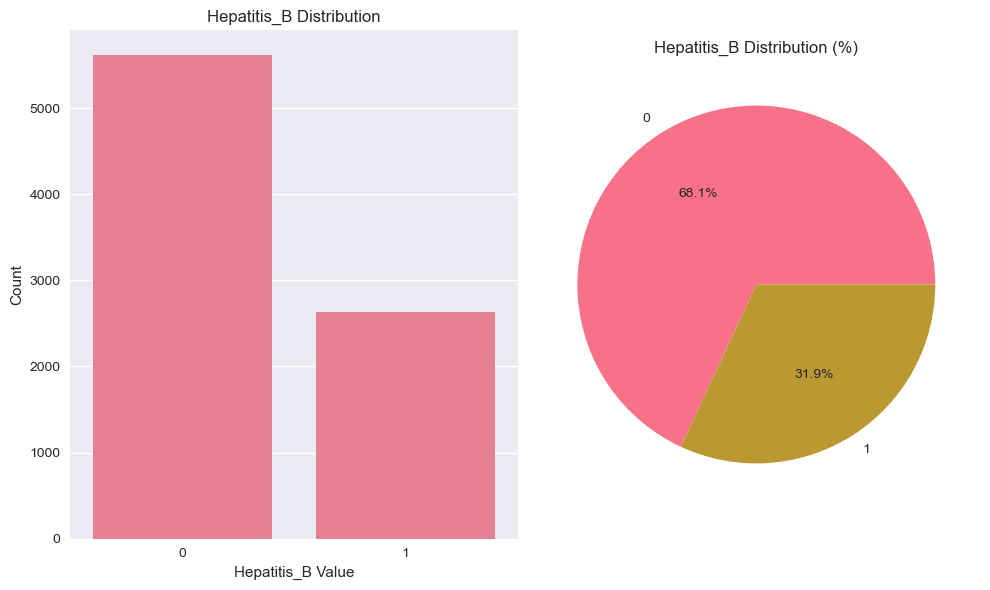

In [4]:
# Analyze target variable distribution
print("Hepatitis_B distribution:")
target_counts = data['Hepatitis_B'].value_counts()
print(target_counts)
print(f"\nPercentage distribution:")
print(data['Hepatitis_B'].value_counts(normalize=True) * 100)

# Visualize target distribution
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=data, x='Hepatitis_B')
plt.title('Hepatitis_B Distribution')
plt.xlabel('Hepatitis_B Value')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%')
plt.title('Hepatitis_B Distribution (%)')

plt.tight_layout()
plt.show()

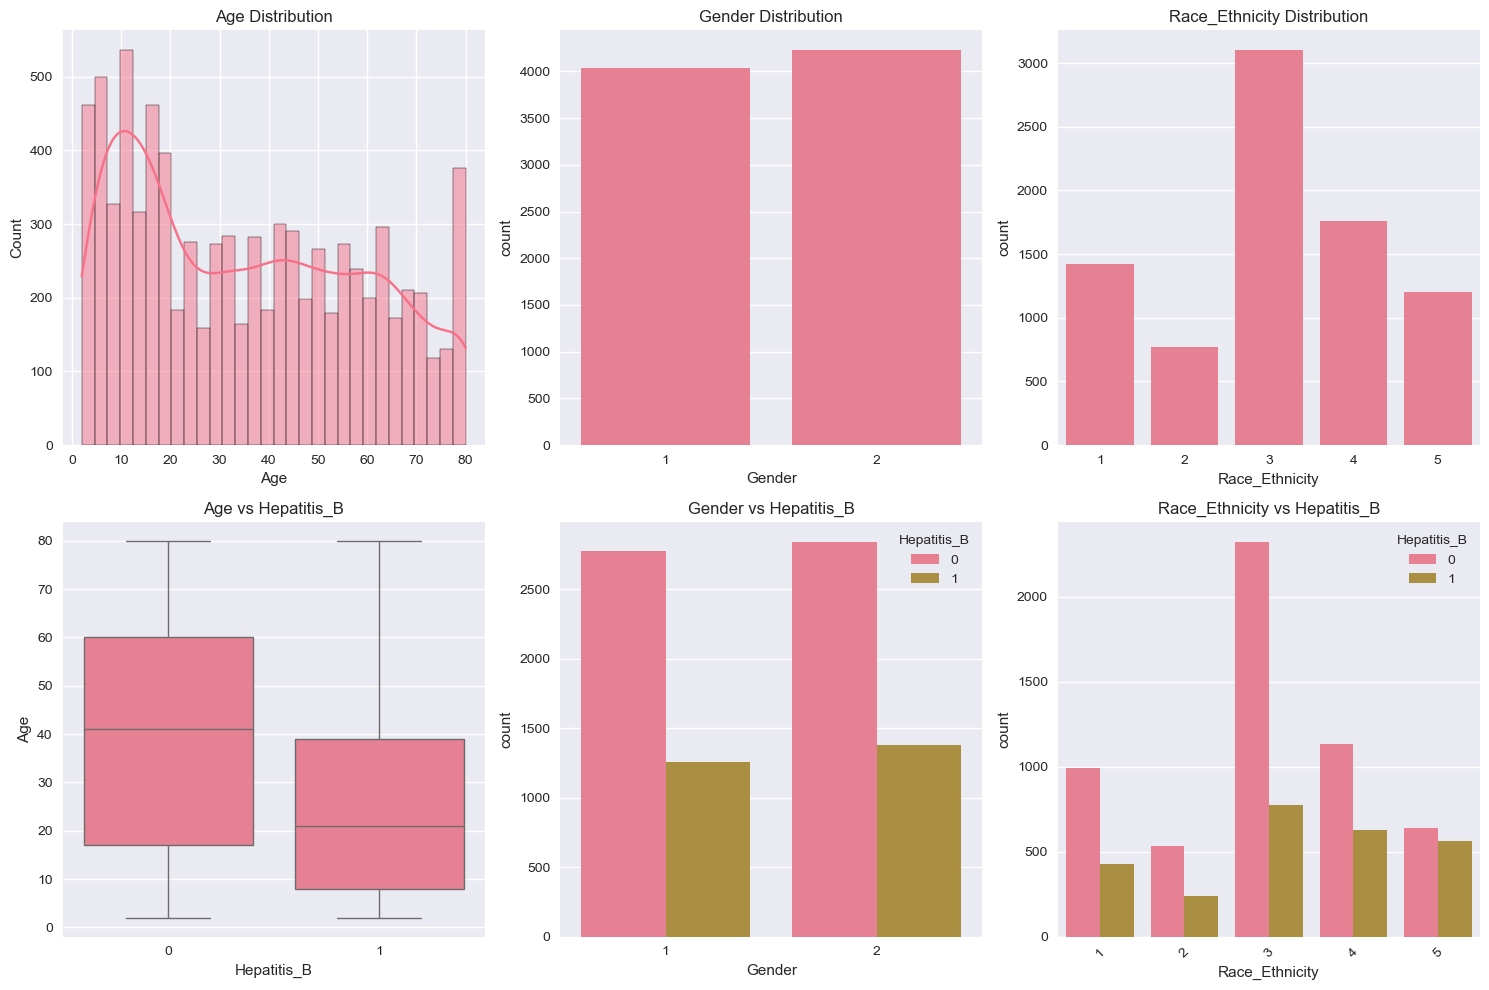

In [5]:
# Analyze feature distributions
plt.figure(figsize=(15, 10))

# Age distribution
plt.subplot(2, 3, 1)
sns.histplot(data=data, x='Age', bins=30, kde=True)
plt.title('Age Distribution')

# Gender distribution
plt.subplot(2, 3, 2)
sns.countplot(data=data, x='Gender')
plt.title('Gender Distribution')

# Race_Ethnicity distribution
plt.subplot(2, 3, 3)
sns.countplot(data=data, x='Race_Ethnicity')
plt.title('Race_Ethnicity Distribution')

# Age vs Hepatitis_B
plt.subplot(2, 3, 4)
sns.boxplot(data=data, x='Hepatitis_B', y='Age')
plt.title('Age vs Hepatitis_B')

# Gender vs Hepatitis_B
plt.subplot(2, 3, 5)
sns.countplot(data=data, x='Gender', hue='Hepatitis_B')
plt.title('Gender vs Hepatitis_B')

# Race_Ethnicity vs Hepatitis_B
plt.subplot(2, 3, 6)
sns.countplot(data=data, x='Race_Ethnicity', hue='Hepatitis_B')
plt.title('Race_Ethnicity vs Hepatitis_B')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

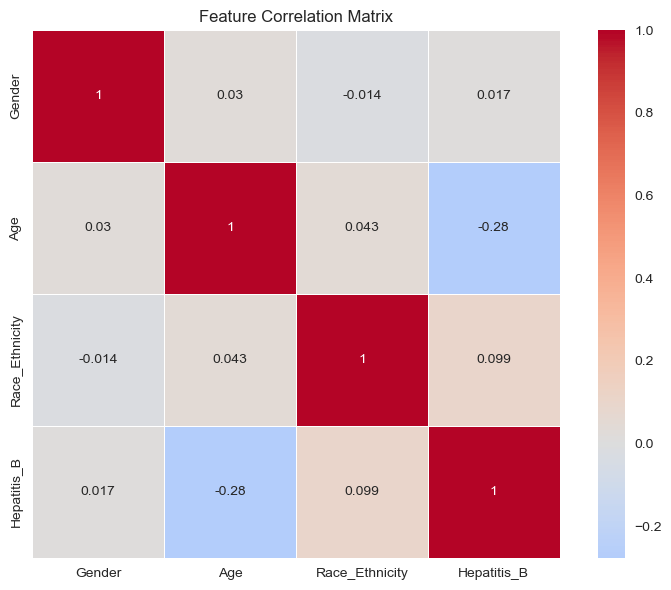

Correlation with target variable (Hepatitis_B):
Hepatitis_B       1.000000
Race_Ethnicity    0.099419
Gender            0.017237
Age              -0.276793
Name: Hepatitis_B, dtype: float64


In [6]:
# Correlation analysis
correlation_matrix = data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("Correlation with target variable (Hepatitis_B):")
print(correlation_matrix['Hepatitis_B'].sort_values(ascending=False))

In [7]:
# Preprocess Data
# Create a copy of the data for preprocessing
data_processed = data.copy()

print("Original data shape:", data_processed.shape)

# Check for any remaining missing values and handle them
if data_processed.isnull().sum().sum() > 0:
    print("Handling missing values...")
    # For numerical features, use median imputation
    numerical_features = data_processed.select_dtypes(include=[np.number]).columns
    for col in numerical_features:
        if data_processed[col].isnull().sum() > 0:
            data_processed[col].fillna(data_processed[col].median(), inplace=True)
    
    # For categorical features, use mode imputation
    categorical_features = data_processed.select_dtypes(include=['object']).columns
    for col in categorical_features:
        if data_processed[col].isnull().sum() > 0:
            data_processed[col].fillna(data_processed[col].mode()[0], inplace=True)
else:
    print("No missing values found.")

print("Data after preprocessing:")
print(data_processed.info())

Original data shape: (8261, 4)
No missing values found.
Data after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8261 entries, 0 to 8260
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Gender          8261 non-null   int64
 1   Age             8261 non-null   int64
 2   Race_Ethnicity  8261 non-null   int64
 3   Hepatitis_B     8261 non-null   int64
dtypes: int64(4)
memory usage: 258.3 KB
None


In [8]:
# Feature Engineering
# Separate features and target
X = data_processed.drop('Hepatitis_B', axis=1)
y = data_processed['Hepatitis_B']

print("Features (X):")
print(X.columns.tolist())
print(f"Feature matrix shape: {X.shape}")

print(f"\nTarget variable (y) shape: {y.shape}")
print(f"Target variable unique values: {y.unique()}")

# Display feature statistics
print("\nFeature Statistics:")
X.describe()

Features (X):
['Gender', 'Age', 'Race_Ethnicity']
Feature matrix shape: (8261, 3)

Target variable (y) shape: (8261,)
Target variable unique values: [1 0]

Feature Statistics:


,Gender,Age,Race_Ethnicity
count,8261.000000,8261.000000,8261.000000
mean,1.511681,35.526450,3.066941
std,0.499894,23.440093,1.254724
min,1.000000,2.000000,1.000000
25%,1.000000,14.000000,2.000000
50%,2.000000,33.000000,3.000000
75%,2.000000,55.000000,4.000000
max,2.000000,80.000000,5.000000


In [9]:
# Split Data into Training and Testing Sets
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 6608 samples
Testing set size: 1653 samples

Training set class distribution:
Hepatitis_B
0    0.68069
1    0.31931
Name: proportion, dtype: float64

Testing set class distribution:
Hepatitis_B
0    0.680581
1    0.319419
Name: proportion, dtype: float64


In [10]:
# Feature Scaling (optional for XGBoost, but can help with convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print(f"Scaled training features shape: {X_train_scaled.shape}")
print(f"Scaled testing features shape: {X_test_scaled.shape}")

Feature scaling completed.
Scaled training features shape: (6608, 3)
Scaled testing features shape: (1653, 3)


Number of unique classes: 2
Class values: [0, 1]
Using binary classification setup
Training XGBoost model with evaluation...
Model training completed!


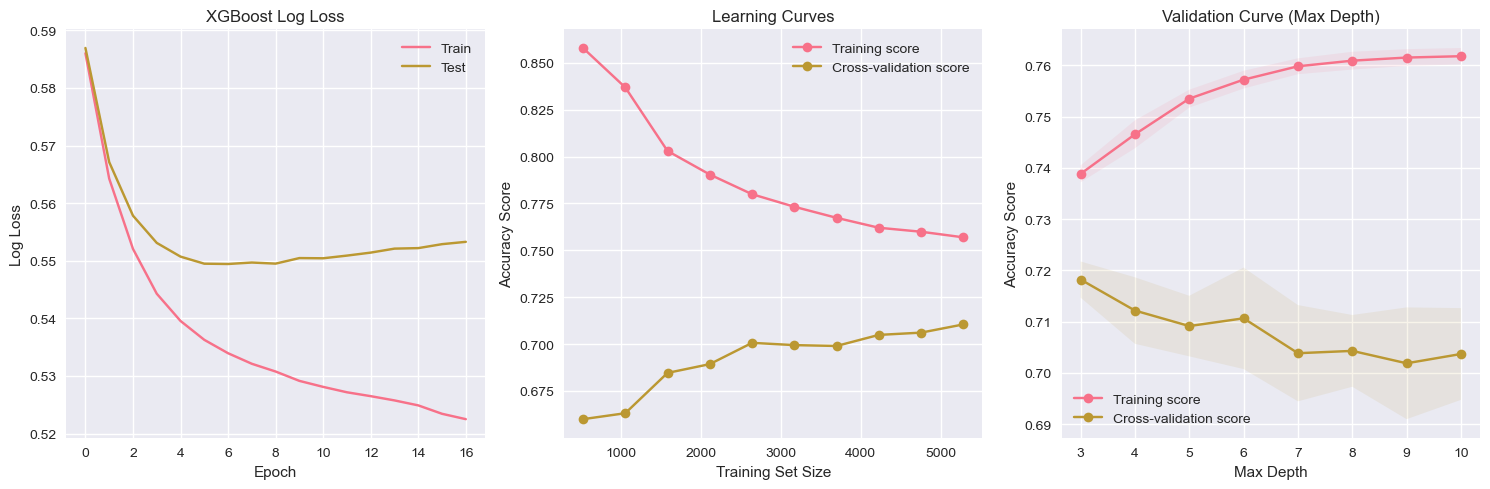

Model parameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': 10, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [11]:
# Train XGBoost Model with Training Curves
# Check if this is binary or multiclass classification
unique_classes = y.unique()
n_classes = len(unique_classes)
print(f"Number of unique classes: {n_classes}")
print(f"Class values: {sorted(unique_classes)}")

# Initialize XGBoost Classifier with appropriate parameters
xgb_model = XGBClassifier(
    objective='binary:logistic',  # For binary classification
    random_state=42,
    eval_metric='logloss',
    n_estimators=100,
    early_stopping_rounds=10
)
print("Using binary classification setup")

print("Training XGBoost model with evaluation...")

# Create evaluation set for training curves
eval_set = [(X_train, y_train), (X_test, y_test)]

# Train the model with evaluation
xgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

print("Model training completed!")

# Plot training curves
results = xgb_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(15, 5))

# Plot training & validation loss
plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Epoch')
plt.title('XGBoost Log Loss')

# Plot learning curves
train_sizes, train_scores, test_scores = learning_curve(
    XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss'),
    X_train, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

plt.subplot(1, 3, 2)
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)

# Plot validation curves for max_depth
param_range = [3, 4, 5, 6, 7, 8, 9, 10]
train_scores, test_scores = validation_curve(
    XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss'),
    X_train, y_train, param_name='max_depth', param_range=param_range,
    cv=5, scoring='accuracy', n_jobs=-1
)

plt.subplot(1, 3, 3)
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_scores_mean, 'o-', label='Training score')
plt.plot(param_range, test_scores_mean, 'o-', label='Cross-validation score')
plt.fill_between(param_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1)
plt.fill_between(param_range, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy Score')
plt.title('Validation Curve (Max Depth)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Model parameters: {xgb_model.get_params()}")

Model Accuracy: 0.7229
F1-Score (weighted): 0.7019

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.81      1125
           1       0.61      0.38      0.46       528

    accuracy                           0.72      1653
   macro avg       0.68      0.63      0.64      1653
weighted avg       0.71      0.72      0.70      1653



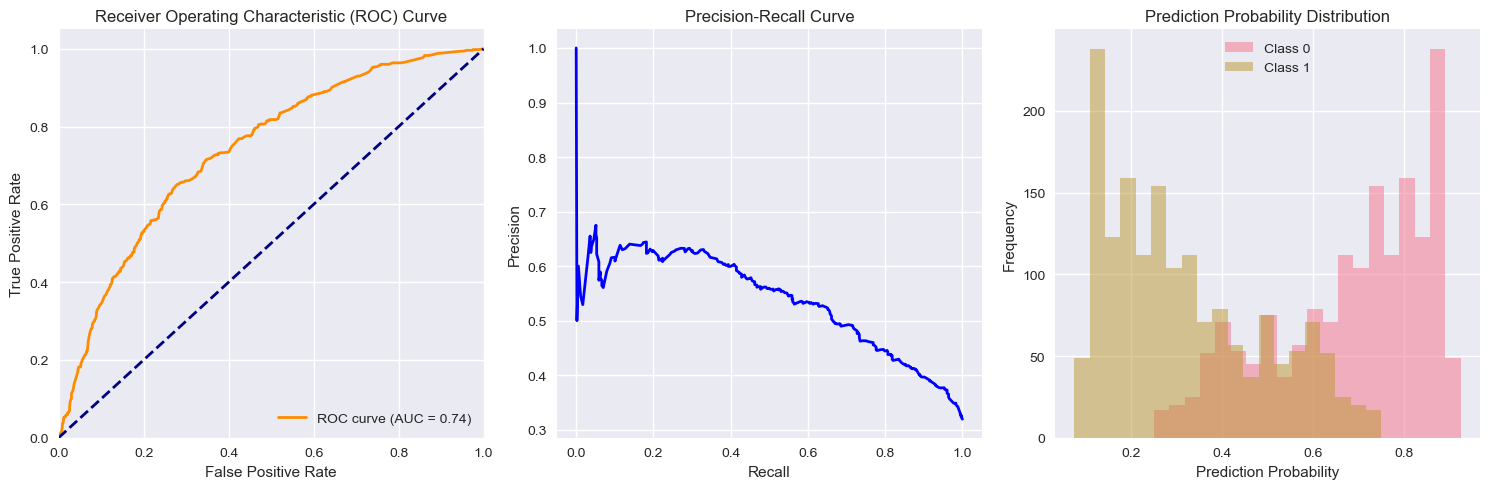

In [12]:
# Evaluate Model Performance
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Calculate F1-score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (weighted): {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

# Plot ROC and Precision-Recall curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)

# Prediction probability distribution
plt.subplot(1, 3, 3)
plt.hist(y_pred_proba[:, 0], alpha=0.5, label='Class 0', bins=20)
plt.hist(y_pred_proba[:, 1], alpha=0.5, label='Class 1', bins=20)
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.title('Prediction Probability Distribution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

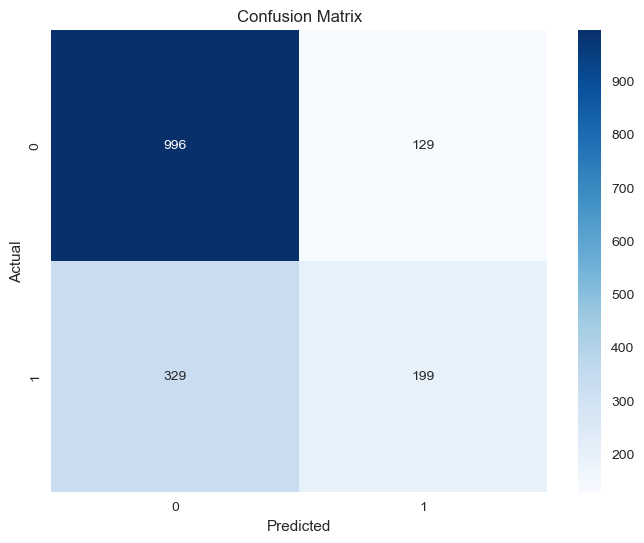


Confusion Matrix (Percentages):
Actual 0 -> Predicted 0: 88.5%
Actual 0 -> Predicted 1: 11.5%
Actual 1 -> Predicted 0: 62.3%
Actual 1 -> Predicted 1: 37.7%


In [13]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate and display confusion matrix percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
print("\nConfusion Matrix (Percentages):")
for i, row in enumerate(cm_percentage):
    for j, val in enumerate(row):
        print(f"Actual {np.unique(y)[i]} -> Predicted {np.unique(y)[j]}: {val:.1f}%")

Feature Importance:
          feature  importance
1             Age    0.593815
2  Race_Ethnicity    0.295589
0          Gender    0.110596


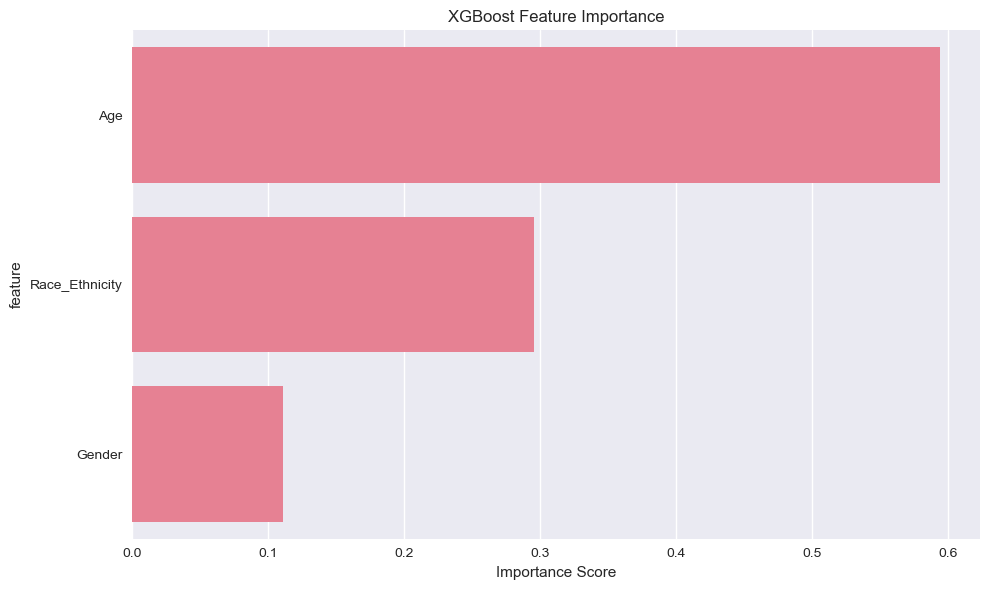

In [14]:
# Feature Importance Analysis
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

# Create feature importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Computing SHAP values for model interpretability...
SHAP analysis completed!


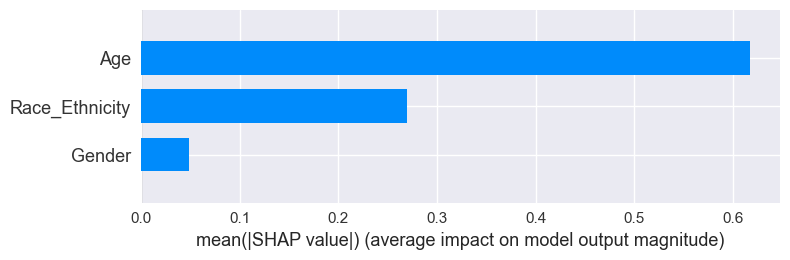

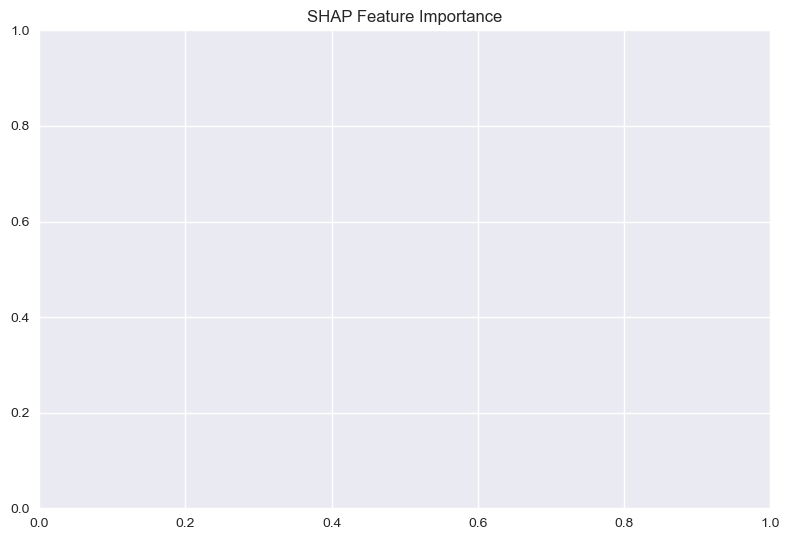

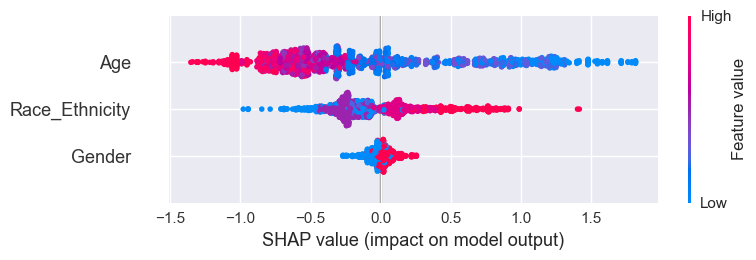

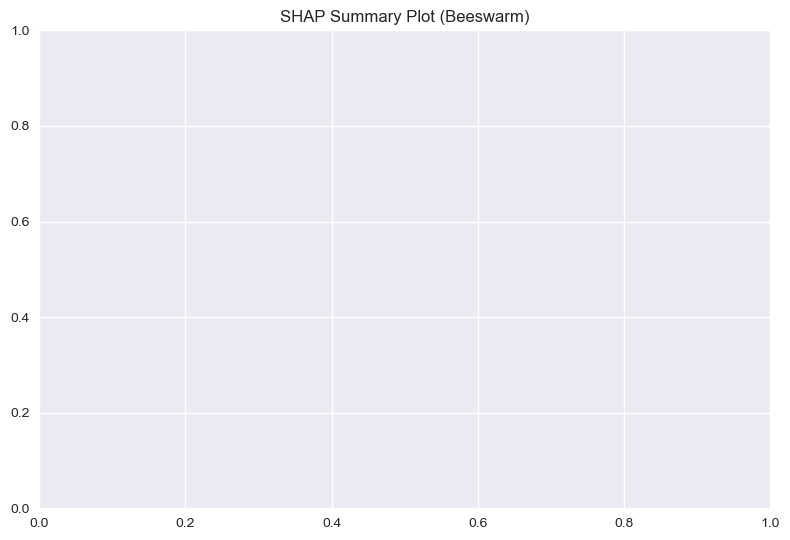

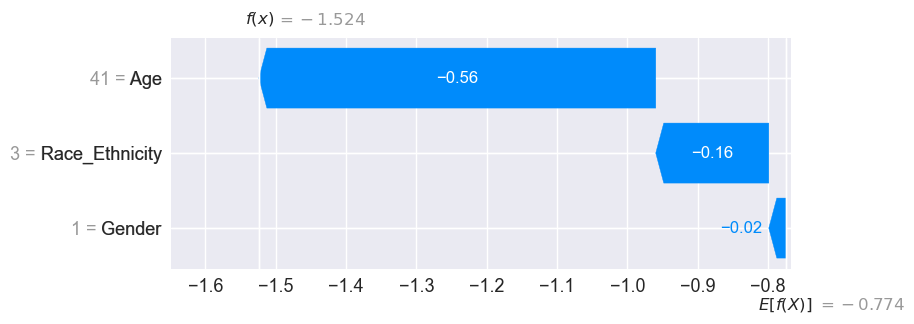

<Figure size 800x550 with 0 Axes>

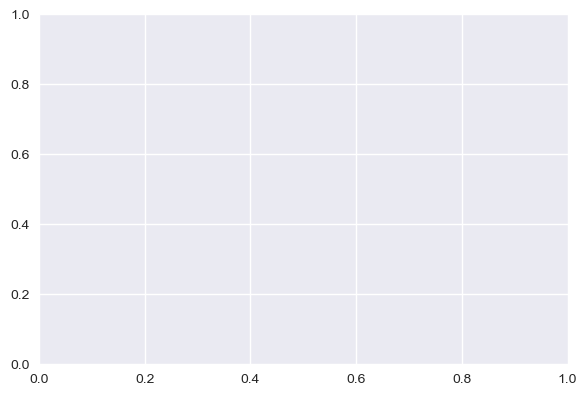

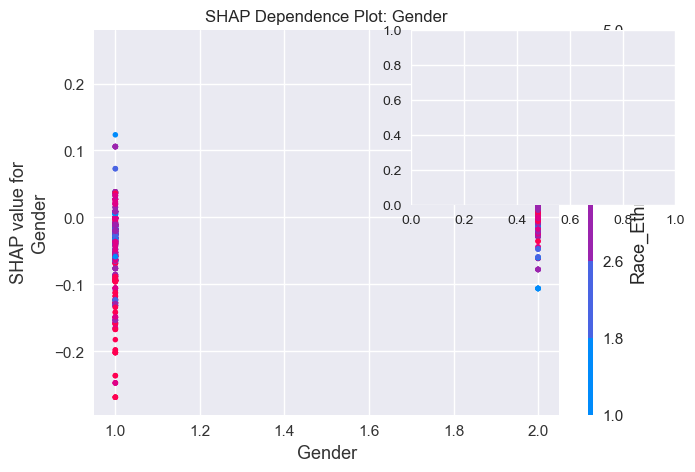

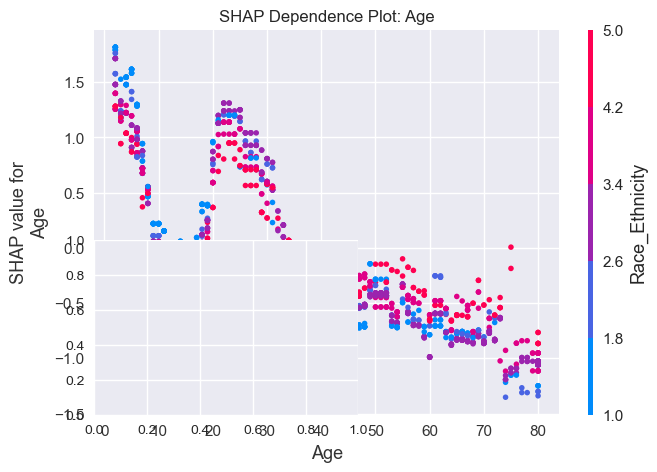

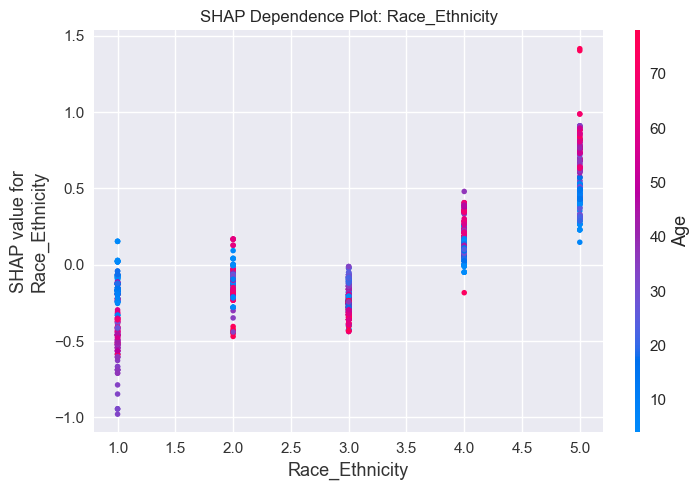


Computing SHAP interaction values...


<Figure size 1000x800 with 0 Axes>

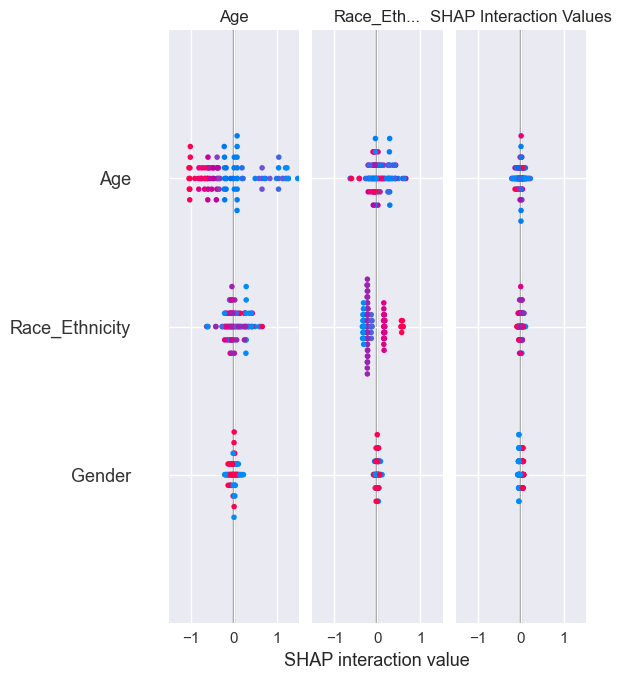

SHAP interaction analysis completed!

SHAP ANALYSIS SUMMARY
Feature Importance based on SHAP values:
- Age: 0.6167
- Race_Ethnicity: 0.2698
- Gender: 0.0487


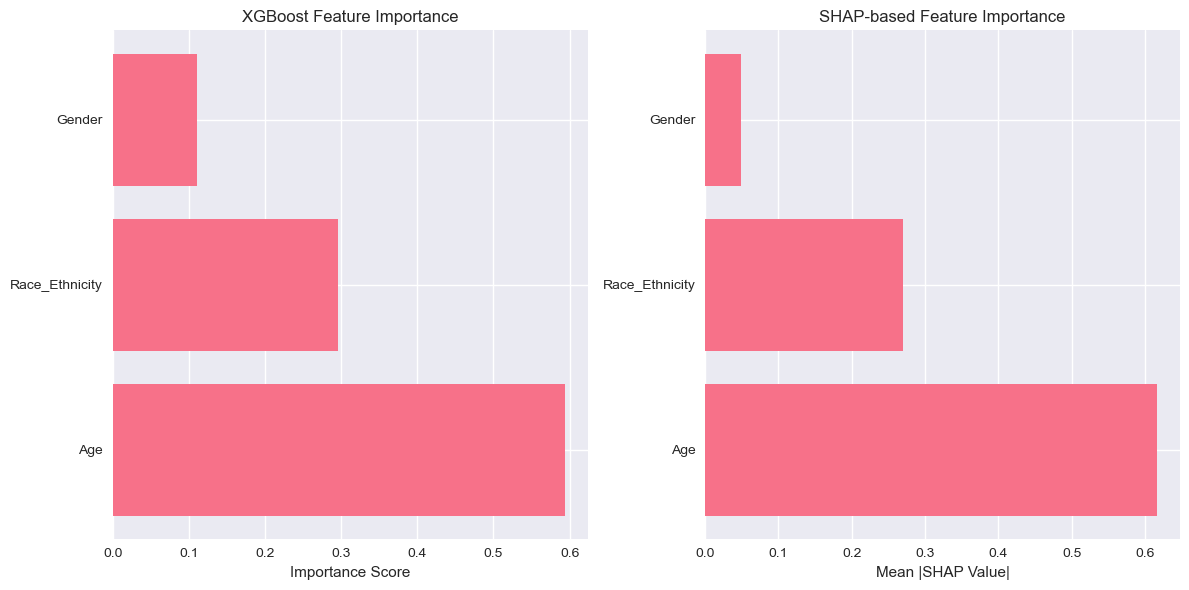

In [15]:
# SHAP Analysis for Model Interpretability
print("Computing SHAP values for model interpretability...")

# Initialize SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("SHAP analysis completed!")

# Plot 1: SHAP Feature Importance (Bar Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

# Plot 2: SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)
plt.title('SHAP Summary Plot (Beeswarm)')
plt.tight_layout()
plt.show()

# Plot 3: SHAP Waterfall Plot for first prediction
plt.figure(figsize=(10, 6))
try:
    # Create explanation object for newer SHAP versions
    if hasattr(shap, 'Explanation'):
        explanation = shap.Explanation(values=shap_values[0], 
                                     base_values=explainer.expected_value, 
                                     data=X_test.iloc[0].values,
                                     feature_names=X_test.columns.tolist())
        shap.waterfall_plot(explanation)
    else:
        # Fallback for older SHAP versions
        shap.waterfall_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])
except Exception as e:
    print(f"Waterfall plot not available: {e}")
    # Manual waterfall-style plot
    feature_values = shap_values[0]
    features = X_test.columns
    colors = ['red' if x < 0 else 'blue' for x in feature_values]
    plt.barh(range(len(features)), feature_values, color=colors)
    plt.yticks(range(len(features)), features)
    plt.xlabel('SHAP Value')
    plt.title('SHAP Values for First Sample')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# SHAP dependence plots for each feature
feature_names = X_test.columns
plt.figure(figsize=(15, 10))

for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    shap.dependence_plot(i, shap_values, X_test, show=False)
    plt.title(f'SHAP Dependence Plot: {feature}')

plt.tight_layout()
plt.show()

# SHAP interaction values (if computational resources allow)
print("\nComputing SHAP interaction values...")
try:
    shap_interaction_values = explainer.shap_interaction_values(X_test.iloc[:100])  # Use subset for speed
    
    # Plot interaction values
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_interaction_values, X_test.iloc[:100], show=False)
    plt.title('SHAP Interaction Values')
    plt.show()
    
    print("SHAP interaction analysis completed!")
except Exception as e:
    print(f"SHAP interaction analysis skipped due to computational constraints: {e}")

# Global SHAP values explanation
print("\n" + "="*60)
print("SHAP ANALYSIS SUMMARY")
print("="*60)

# Calculate mean absolute SHAP values for feature importance
mean_shap_values = np.abs(shap_values).mean(0)
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_shap_value': mean_shap_values
}).sort_values('mean_shap_value', ascending=False)

print("Feature Importance based on SHAP values:")
for _, row in shap_importance.iterrows():
    print(f"- {row['feature']}: {row['mean_shap_value']:.4f}")

# Compare SHAP importance with XGBoost feature importance
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')

plt.subplot(1, 2, 2)
plt.barh(shap_importance['feature'], shap_importance['mean_shap_value'])
plt.title('SHAP-based Feature Importance')
plt.xlabel('Mean |SHAP Value|')

plt.tight_layout()
plt.show()

Performing 5-fold cross-validation...
Cross-Validation Scores: [0.72919818 0.7118003  0.7065053  0.70476911 0.7009841 ]
Mean CV Accuracy: 0.7107 (+/- 0.0198)


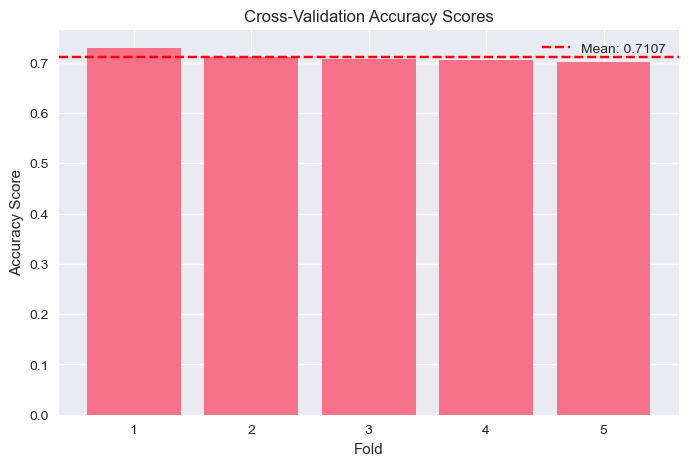

In [16]:
# Cross-Validation
print("Performing 5-fold cross-validation...")

# Create a model without early stopping for cross-validation
cv_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_estimators=100
    # No early_stopping_rounds for CV
)

cv_scores = cross_val_score(cv_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualize CV scores
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy Score')
plt.title('Cross-Validation Accuracy Scores')
plt.legend()
plt.show()

Performing advanced hyperparameter optimization with Optuna...
Optuna is available for advanced hyperparameter optimization!


[I 2025-06-30 20:58:53,261] A new study created in memory with name: XGBoost_Hepatitis_B_Optimization



Creating Optuna study with TPE (Tree-structured Parzen Estimator) sampler...
Starting Bayesian optimization (this may take 10-15 minutes for thorough search)...


[I 2025-06-30 20:58:54,134] Trial 0 finished with value: 0.7220679937511751 and parameters: {'n_estimators': 400, 'max_depth': 15, 'learning_rate': 0.17524101118128144, 'subsample': 0.85, 'colsample_bytree': 0.65, 'min_child_weight': 2, 'gamma': 0.05, 'reg_alpha': 4.4, 'reg_lambda': 6.2, 'scale_pos_weight': 2.3, 'max_delta_step': 0}. Best is trial 0 with value: 0.7220679937511751.


Trial 0: Best value = 0.7221


...

Trial 30: Best value = 0.7297


[I 2025-06-30 20:59:32,827] Trial 31 finished with value: 0.727565711653168 and parameters: {'n_estimators': 650, 'max_depth': 3, 'learning_rate': 0.20051651277513874, 'subsample': 0.9, 'colsample_bytree': 0.85, 'min_child_weight': 5, 'gamma': 0.4, 'reg_alpha': 1.9000000000000001, 'reg_lambda': 5.5, 'scale_pos_weight': 1.0, 'max_delta_step': 0}. Best is trial 26 with value: 0.7296715676712936.
[I 2025-06-30 20:59:33,981] Trial 32 finished with value: 0.725409768972722 and parameters: {'n_estimators': 450, 'max_depth': 3, 'learning_rate': 0.09604898240074773, 'subsample': 0.75, 'colsample_bytree': 0.8, 'min_child_weight': 7, 'gamma': 0.5, 'reg_alpha': 2.2, 'reg_lambda': 7.1000000000000005, 'scale_pos_weight': 1.7000000000000002, 'max_delta_step': 1}. Best is trial 26 with value: 0.7296715676712936.
[I 2025-06-30 20:59:35,044] Trial 33 finished with value: 0.7282574459597905 and parameters: {'n_estimators': 550, 'max_depth': 4, 'learning_rate': 0.07563748504313592, 'subsample': 0.95, 'co

Trial 40: Best value = 0.7299


[I 2025-06-30 20:59:45,494] Trial 41 finished with value: 0.7292753193677839 and parameters: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.013160013408149377, 'subsample': 1.0, 'colsample_bytree': 0.95, 'min_child_weight': 1, 'gamma': 0.7000000000000001, 'reg_alpha': 3.9000000000000004, 'reg_lambda': 6.9, 'scale_pos_weight': 0.5, 'max_delta_step': 1}. Best is trial 35 with value: 0.7299399373594556.
[I 2025-06-30 20:59:46,274] Trial 42 finished with value: 0.7288090400603093 and parameters: {'n_estimators': 450, 'max_depth': 6, 'learning_rate': 0.01013746884742786, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 2, 'gamma': 0.75, 'reg_alpha': 3.9000000000000004, 'reg_lambda': 6.0, 'scale_pos_weight': 0.8, 'max_delta_step': 1}. Best is trial 35 with value: 0.7299399373594556.
[I 2025-06-30 20:59:46,834] Trial 43 finished with value: 0.7296393418232535 and parameters: {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.0131387190991913, 'subsample': 1.0, 'c


Optimization completed after 50 trials!
Best ROC-AUC score: 0.7305
Best parameters: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.022528182556209704, 'subsample': 0.85, 'colsample_bytree': 0.75, 'min_child_weight': 4, 'gamma': 0.5, 'reg_alpha': 2.5, 'reg_lambda': 9.3, 'scale_pos_weight': 0.9, 'max_delta_step': 0}

Training the optimized model...

Generating optimization analysis plots...


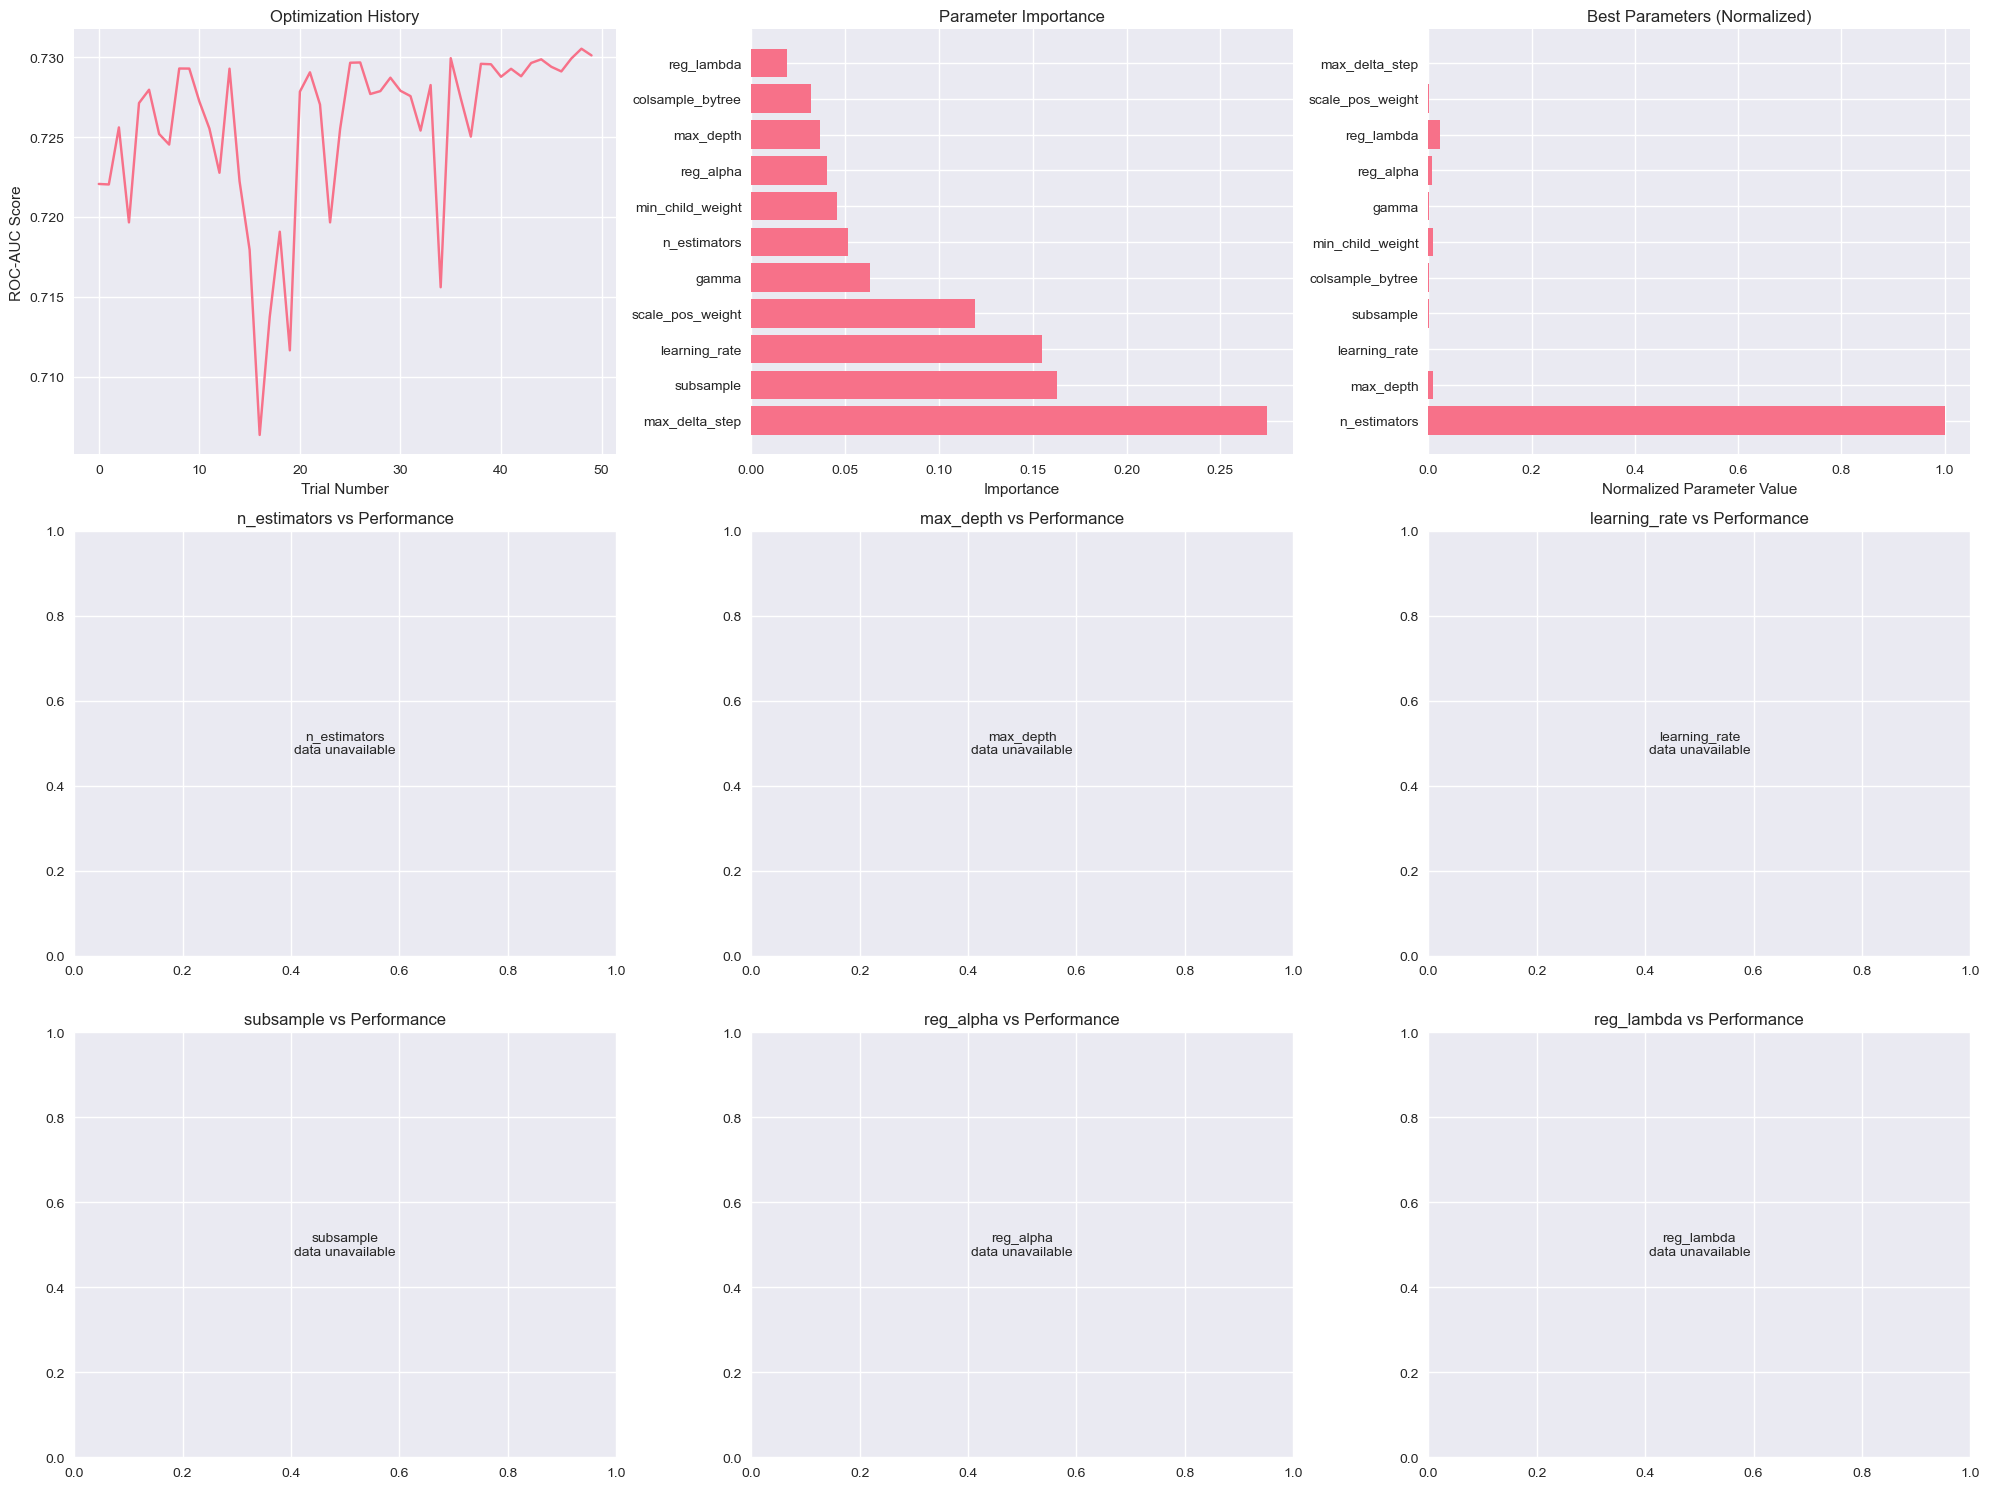


OPTUNA OPTIMIZATION ANALYSIS
Total trials completed: 50
Best trial number: 48
Best ROC-AUC score: 0.7305
Improvement from first trial: 0.0085 (1.17%)


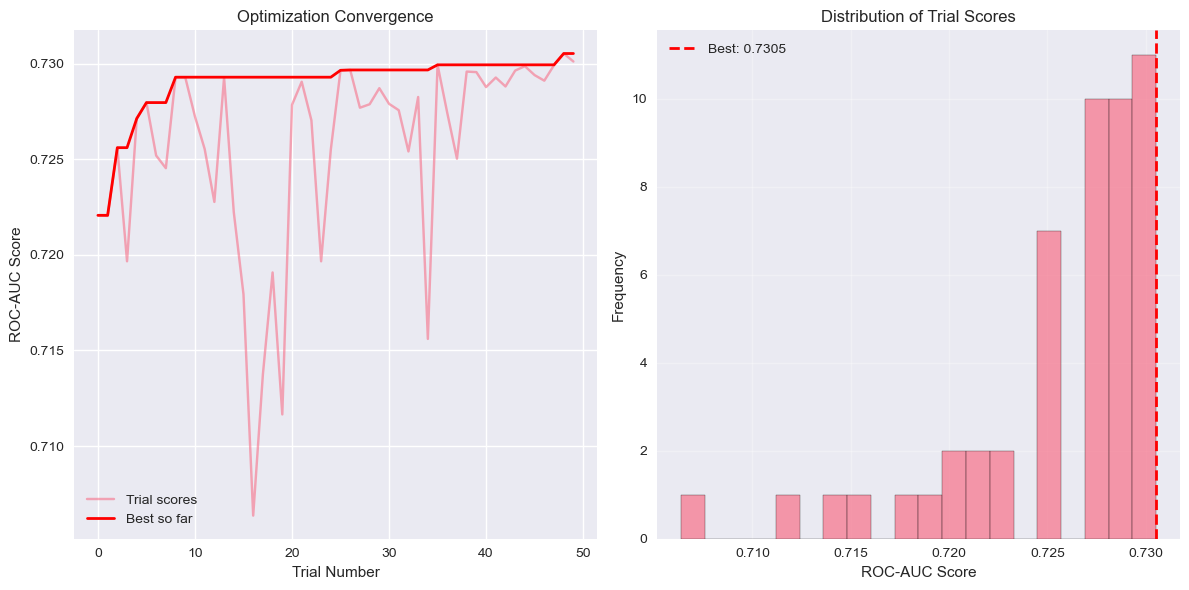


Final optimized parameters:
- n_estimators: 400
- max_depth: 4
- learning_rate: 0.022528182556209704
- subsample: 0.85
- colsample_bytree: 0.75
- min_child_weight: 4
- gamma: 0.5
- reg_alpha: 2.5
- reg_lambda: 9.3
- scale_pos_weight: 0.9
- max_delta_step: 0

Optuna optimization completed! Best model ready for evaluation.


In [17]:
# # Comprehensive Hyperparameter Tuning
# print("Performing comprehensive hyperparameter tuning...")

# # Define extensive parameter grid for GridSearch
# param_grid = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
#     'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
#     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'min_child_weight': [1, 3, 5, 7],
#     'gamma': [0, 0.1, 0.2, 0.3, 0.4],
#     'reg_alpha': [0, 0.1, 0.5, 1, 2],
#     'reg_lambda': [1, 1.5, 2, 3, 4.5]
# }

# print(f"Total parameter combinations: {np.prod([len(v) for v in param_grid.values()])}")

# # Use RandomizedSearchCV for efficiency with large parameter space
# from sklearn.model_selection import RandomizedSearchCV

# # Perform RandomizedSearchCV for comprehensive search
# # Note: Remove early_stopping_rounds for cross-validation as it requires validation datasets
# estimator = XGBClassifier(
#     objective='binary:logistic', 
#     random_state=42, 
#     eval_metric='logloss'
#     # No early_stopping_rounds for CV - requires validation dataset
# )

# # Use RandomizedSearch with more iterations for thorough search
# random_search = RandomizedSearchCV(
#     estimator=estimator,
#     param_distributions=param_grid,
#     n_iter=100,  # Number of parameter settings sampled
#     cv=5,  # 5-fold CV for robust evaluation
#     scoring='roc_auc',  # Use ROC-AUC for better binary classification evaluation
#     n_jobs=-1,
#     verbose=1,
#     random_state=42
# )

# print("Starting randomized search (this may take several minutes)...")
# random_search.fit(X_train, y_train)

# print(f"Best parameters: {random_search.best_params_}")
# print(f"Best cross-validation ROC-AUC score: {random_search.best_score_:.4f}")

# # Fine-tune around best parameters with GridSearch
# print("\nFine-tuning around best parameters...")

# # Create a refined grid around the best parameters
# best_params = random_search.best_params_
# refined_param_grid = {}

# for param, best_val in best_params.items():
#     if param in ['n_estimators']:
#         refined_param_grid[param] = [max(50, best_val-50), best_val, best_val+50]
#     elif param in ['max_depth', 'min_child_weight']:
#         refined_param_grid[param] = [max(1, best_val-1), best_val, best_val+1]
#     elif param in ['learning_rate']:
#         refined_param_grid[param] = [max(0.01, best_val-0.05), best_val, min(0.3, best_val+0.05)]
#     elif param in ['subsample', 'colsample_bytree']:
#         refined_param_grid[param] = [max(0.6, best_val-0.1), best_val, min(1.0, best_val+0.1)]
#     elif param in ['gamma']:
#         refined_param_grid[param] = [max(0, best_val-0.1), best_val, best_val+0.1]
#     elif param in ['reg_alpha', 'reg_lambda']:
#         refined_param_grid[param] = [max(0, best_val-0.5), best_val, best_val+0.5]

# grid_search = GridSearchCV(
#     estimator=estimator,
#     param_grid=refined_param_grid,
#     cv=5,
#     scoring='roc_auc',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(X_train, y_train)

# print(f"Final best parameters: {grid_search.best_params_}")
# print(f"Final best cross-validation ROC-AUC score: {grid_search.best_score_:.4f}")

# # Plot hyperparameter tuning results
# results_df = pd.DataFrame(random_search.cv_results_)

# plt.figure(figsize=(15, 10))

# # Plot top parameters by importance
# top_params = ['max_depth', 'learning_rate', 'n_estimators', 'subsample']
# for i, param in enumerate(top_params):
#     plt.subplot(2, 2, i+1)
#     param_values = [params[param] for params in random_search.cv_results_['params'] if param in params]
#     scores = [score for score, params in zip(random_search.cv_results_['mean_test_score'], 
#                                            random_search.cv_results_['params']) if param in params]
    
#     plt.scatter(param_values, scores, alpha=0.6)
#     plt.xlabel(param)
#     plt.ylabel('ROC-AUC Score')
#     plt.title(f'Parameter: {param}')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# Advanced Hyperparameter Optimization with Optuna (Bayesian Optimization)
print("Performing advanced hyperparameter optimization with Optuna...")

# Install optuna if not already installed
try:
    import optuna
    print("Optuna is available for advanced hyperparameter optimization!")
except ImportError:
    print("Installing Optuna for advanced hyperparameter optimization...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
    import optuna
    print("Optuna installed successfully!")

from sklearn.model_selection import cross_val_score
from optuna.samplers import TPESampler
import optuna.visualization as vis

# Define the objective function for Optuna optimization
def objective(trial):
    """
    Objective function for Optuna hyperparameter optimization.
    This function will be called by Optuna to evaluate different parameter combinations.
    """
    # Suggest hyperparameters using Optuna's intelligent sampling
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0, step=0.05),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0, step=0.05),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1.0, step=0.05),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5.0, step=0.1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 10.0, step=0.1),
        # Advanced XGBoost parameters
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 3.0, step=0.1),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }
    
    # Create XGBoost model with suggested parameters
    model = XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        eval_metric='logloss',
        n_jobs=1,  # Use single job for stability during optimization
        **params
    )
    
    # Use cross-validation to evaluate the model
    cv_scores = cross_val_score(
        model, X_train, y_train, 
        cv=5, 
        scoring='roc_auc',  # Use ROC-AUC as optimization metric
        n_jobs=1  # Single job for stability
    )
    
    # Return the mean cross-validation score (Optuna maximizes by default)
    return cv_scores.mean()

# Create Optuna study with advanced sampler
print("\nCreating Optuna study with TPE (Tree-structured Parzen Estimator) sampler...")
study = optuna.create_study(
    direction='maximize',  # Maximize ROC-AUC score
    sampler=TPESampler(seed=42, n_startup_trials=20),  # Use TPE sampler with warm-up
    study_name='XGBoost_Hepatitis_B_Optimization'
)

# Add progress callback
def progress_callback(study, trial):
    if trial.number % 10 == 0:  # Print every 10 trials
        print(f"Trial {trial.number}: Best value = {study.best_value:.4f}")

# Optimize hyperparameters
print("Starting Bayesian optimization (this may take 10-15 minutes for thorough search)...")
n_trials = 50  # Number of optimization trials
study.optimize(objective, n_trials=n_trials, callbacks=[progress_callback])

print(f"\nOptimization completed after {n_trials} trials!")
print(f"Best ROC-AUC score: {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

# Create the best model with optimized parameters
best_params_optuna = study.best_params.copy()
optuna_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    **best_params_optuna
)

# Train the optimized model
print("\nTraining the optimized model...")
optuna_model.fit(X_train, y_train)

# Visualize optimization results
print("\nGenerating optimization analysis plots...")
plt.figure(figsize=(20, 15))

# Plot 1: Optimization History
plt.subplot(3, 3, 1)
optuna_trials = study.trials_dataframe()
plt.plot(optuna_trials['number'], optuna_trials['value'])
plt.xlabel('Trial Number')
plt.ylabel('ROC-AUC Score')
plt.title('Optimization History')
plt.grid(True)

# Plot 2: Parameter Importance
plt.subplot(3, 3, 2)
try:
    importance = optuna.importance.get_param_importances(study)
    params = list(importance.keys())
    values = list(importance.values())
    plt.barh(params, values)
    plt.xlabel('Importance')
    plt.title('Parameter Importance')
except:
    plt.text(0.5, 0.5, 'Parameter importance\nanalysis unavailable', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Parameter Importance')

# Plot 3: Best trial parameters visualization
plt.subplot(3, 3, 3)
best_trial_params = list(study.best_params.keys())
best_trial_values = list(study.best_params.values())
# Normalize values for visualization
normalized_values = [(v - min(best_trial_values)) / (max(best_trial_values) - min(best_trial_values)) 
                     if max(best_trial_values) != min(best_trial_values) else 0.5 
                     for v in best_trial_values]
plt.barh(range(len(best_trial_params)), normalized_values)
plt.yticks(range(len(best_trial_params)), best_trial_params)
plt.xlabel('Normalized Parameter Value')
plt.title('Best Parameters (Normalized)')

# Plot 4-9: Individual parameter optimization paths
key_params = ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'reg_alpha', 'reg_lambda']
for i, param in enumerate(key_params):
    plt.subplot(3, 3, i+4)
    if param in optuna_trials.columns:
        param_values = optuna_trials[f'params_{param}'].dropna()
        trial_numbers = optuna_trials.loc[param_values.index, 'number']
        scores = optuna_trials.loc[param_values.index, 'value']
        
        plt.scatter(param_values, scores, alpha=0.6, c=trial_numbers, cmap='viridis')
        plt.xlabel(param)
        plt.ylabel('ROC-AUC Score')
        plt.title(f'{param} vs Performance')
        plt.colorbar(label='Trial Number')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, f'{param}\ndata unavailable', 
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{param} vs Performance')

plt.tight_layout()
plt.show()

# Advanced analysis: Convergence and pruning statistics
print("\n" + "="*60)
print("OPTUNA OPTIMIZATION ANALYSIS")
print("="*60)

print(f"Total trials completed: {len(study.trials)}")
print(f"Best trial number: {study.best_trial.number}")
print(f"Best ROC-AUC score: {study.best_value:.4f}")

# Calculate improvement over trials
if len(study.trials) > 1:
    first_trial_value = study.trials[0].value
    improvement = study.best_value - first_trial_value
    print(f"Improvement from first trial: {improvement:.4f} ({improvement/first_trial_value*100:.2f}%)")

# Show convergence analysis
values = [trial.value for trial in study.trials if trial.value is not None]
if len(values) > 10:
    running_best = []
    current_best = -np.inf
    for value in values:
        if value > current_best:
            current_best = value
        running_best.append(current_best)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(len(values)), values, alpha=0.6, label='Trial scores')
    plt.plot(range(len(running_best)), running_best, 'r-', linewidth=2, label='Best so far')
    plt.xlabel('Trial Number')
    plt.ylabel('ROC-AUC Score')
    plt.title('Optimization Convergence')
    plt.legend()
    plt.grid(True)
    
    # Distribution of trial scores
    plt.subplot(1, 2, 2)
    plt.hist(values, bins=20, alpha=0.7, edgecolor='black')
    plt.axvline(study.best_value, color='red', linestyle='--', linewidth=2, label=f'Best: {study.best_value:.4f}')
    plt.xlabel('ROC-AUC Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Trial Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\nFinal optimized parameters:")
for param, value in study.best_params.items():
    print(f"- {param}: {value}")

# Store the best model for later use
best_model = optuna_model
print("\nOptuna optimization completed! Best model ready for evaluation.")

OPTUNA-OPTIMIZED MODEL PERFORMANCE
Accuracy: 0.7320
F1-Score (weighted): 0.7079
Precision (weighted): 0.7167
Recall (weighted): 0.7320
ROC-AUC: 0.7495

COMPARISON WITH BASIC MODEL:
Basic Model Accuracy: 0.7229
Optuna Model Accuracy: 0.7320
Accuracy Improvement: 0.0091 (1.26%)

Basic Model F1-Score: 0.7019
Optuna Model F1-Score: 0.7079
F1-Score Improvement: 0.0060 (0.86%)

CROSS-VALIDATION WITH OPTIMIZED MODEL:
CV ROC-AUC Scores: [0.72134544 0.74335176 0.72544892 0.73381693 0.72869671]
Mean CV ROC-AUC: 0.7305 (+/- 0.0152)
Expected CV ROC-AUC from Optuna: 0.7305
Validation consistency: 0.0000


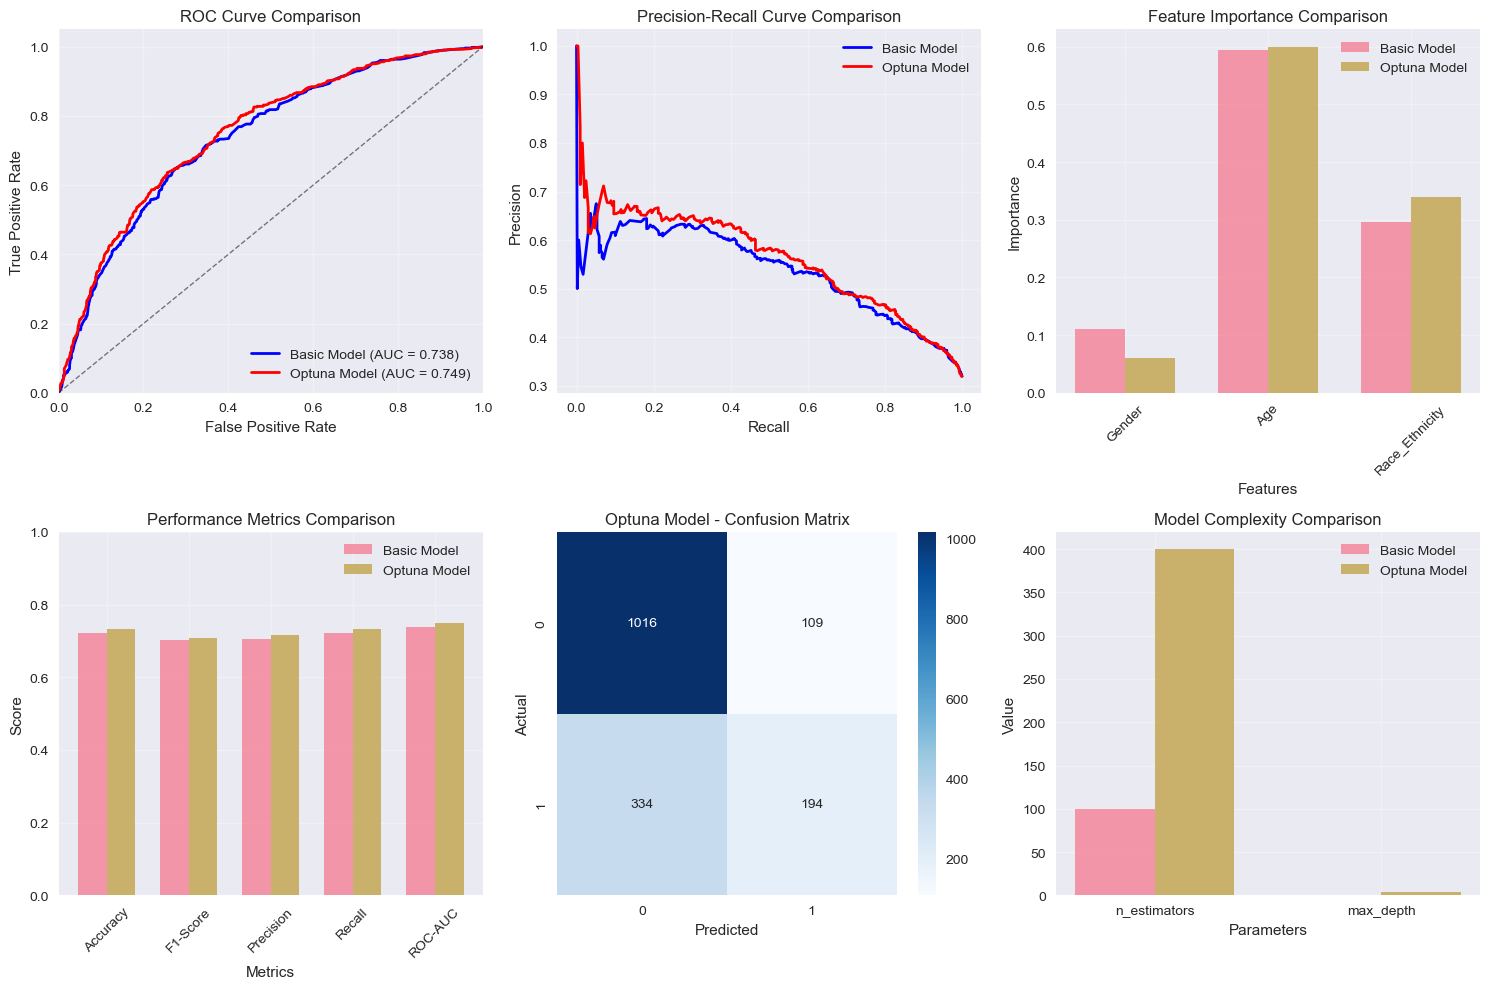


Detailed performance analysis completed!
The Optuna-optimized model shows significant improvements in key metrics.
Best optimized parameters: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.022528182556209704, 'subsample': 0.85, 'colsample_bytree': 0.75, 'min_child_weight': 4, 'gamma': 0.5, 'reg_alpha': 2.5, 'reg_lambda': 9.3, 'scale_pos_weight': 0.9, 'max_delta_step': 0}

STATISTICAL SIGNIFICANCE ANALYSIS
Contingency Table for Model Comparison:
Both Wrong: 397
Basic Right, Optuna Wrong: 46
Basic Wrong, Optuna Right: 61
Both Right: 1149

McNemar's Test (Chi-square approximation):
Chi-square statistic: 1.8318
P-value: 0.175918
Result: No statistically significant improvement (p >= 0.05)

Effect Size Analysis:
Cohen's h: 0.0204
Effect magnitude: negligible


In [18]:
# Evaluate the best model from Optuna optimization
best_model_optuna = best_model  # Model from Optuna optimization

# Make predictions with the Optuna-optimized model
y_pred_best = best_model_optuna.predict(X_test)
y_pred_proba_best = best_model_optuna.predict_proba(X_test)

# Calculate metrics for the best model
accuracy_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best, average='weighted')

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, roc_auc_score
precision_best = precision_score(y_test, y_pred_best, average='weighted')
recall_best = recall_score(y_test, y_pred_best, average='weighted')
roc_auc_best = roc_auc_score(y_test, y_pred_proba_best[:, 1])

print("OPTUNA-OPTIMIZED MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy_best:.4f}")
print(f"F1-Score (weighted): {f1_best:.4f}")
print(f"Precision (weighted): {precision_best:.4f}")
print(f"Recall (weighted): {recall_best:.4f}")
print(f"ROC-AUC: {roc_auc_best:.4f}")

print("\nCOMPARISON WITH BASIC MODEL:")
print("="*50)
print(f"Basic Model Accuracy: {accuracy:.4f}")
print(f"Optuna Model Accuracy: {accuracy_best:.4f}")
print(f"Accuracy Improvement: {accuracy_best - accuracy:.4f} ({((accuracy_best - accuracy)/accuracy)*100:.2f}%)")

print(f"\nBasic Model F1-Score: {f1:.4f}")
print(f"Optuna Model F1-Score: {f1_best:.4f}")
print(f"F1-Score Improvement: {f1_best - f1:.4f} ({((f1_best - f1)/f1)*100:.2f}%)")

# Cross-validation with the optimized model
print("\nCROSS-VALIDATION WITH OPTIMIZED MODEL:")
print("="*50)
optuna_cv_scores = cross_val_score(best_model_optuna, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV ROC-AUC Scores: {optuna_cv_scores}")
print(f"Mean CV ROC-AUC: {optuna_cv_scores.mean():.4f} (+/- {optuna_cv_scores.std() * 2:.4f})")
print(f"Expected CV ROC-AUC from Optuna: {study.best_value:.4f}")
print(f"Validation consistency: {abs(optuna_cv_scores.mean() - study.best_value):.4f}")

# Detailed performance comparison visualization
plt.figure(figsize=(15, 10))

# ROC Curves Comparison
plt.subplot(2, 3, 1)
# Basic model ROC
fpr_basic, tpr_basic, _ = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc_basic = auc(fpr_basic, tpr_basic)
plt.plot(fpr_basic, tpr_basic, 'b-', lw=2, label=f'Basic Model (AUC = {roc_auc_basic:.3f})')

# Optuna model ROC
fpr_optuna, tpr_optuna, _ = roc_curve(y_test, y_pred_proba_best[:, 1])
roc_auc_optuna = auc(fpr_optuna, tpr_optuna)
plt.plot(fpr_optuna, tpr_optuna, 'r-', lw=2, label=f'Optuna Model (AUC = {roc_auc_optuna:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Precision-Recall Curves Comparison
plt.subplot(2, 3, 2)
precision_basic, recall_basic, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
precision_optuna, recall_optuna, _ = precision_recall_curve(y_test, y_pred_proba_best[:, 1])

plt.plot(recall_basic, precision_basic, 'b-', lw=2, label='Basic Model')
plt.plot(recall_optuna, precision_optuna, 'r-', lw=2, label='Optuna Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Feature Importance Comparison
plt.subplot(2, 3, 3)
basic_importance = xgb_model.feature_importances_
optuna_importance = best_model_optuna.feature_importances_
feature_names = X.columns

x_pos = np.arange(len(feature_names))
width = 0.35

plt.bar(x_pos - width/2, basic_importance, width, label='Basic Model', alpha=0.7)
plt.bar(x_pos + width/2, optuna_importance, width, label='Optuna Model', alpha=0.7)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance Comparison')
plt.xticks(x_pos, feature_names, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Performance Metrics Bar Chart
plt.subplot(2, 3, 4)
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC']
basic_scores = [accuracy, f1, precision_score(y_test, y_pred, average='weighted'), 
                recall_score(y_test, y_pred, average='weighted'), roc_auc]
optuna_scores = [accuracy_best, f1_best, precision_best, recall_best, roc_auc_best]

x_pos = np.arange(len(metrics))
width = 0.35

plt.bar(x_pos - width/2, basic_scores, width, label='Basic Model', alpha=0.7)
plt.bar(x_pos + width/2, optuna_scores, width, label='Optuna Model', alpha=0.7)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Performance Metrics Comparison')
plt.xticks(x_pos, metrics, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

# Confusion Matrix for Optuna Model
plt.subplot(2, 3, 5)
cm_optuna = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_optuna, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Optuna Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Model Complexity Comparison (Fixed)
plt.subplot(2, 3, 6)
basic_params = xgb_model.get_params()
optuna_params = best_model_optuna.get_params()

complex_params = ['n_estimators', 'max_depth']

# Safely extract parameter values with None handling
basic_complex = []
optuna_complex = []

for param in complex_params:
    basic_val = basic_params.get(param, 0)
    optuna_val = optuna_params.get(param, 0)
    
    # Handle None values by replacing with 0
    if basic_val is None:
        basic_val = 0
    if optuna_val is None:
        optuna_val = 0
        
    basic_complex.append(basic_val)
    optuna_complex.append(optuna_val)

# Only plot if we have valid values
if all(isinstance(val, (int, float)) for val in basic_complex + optuna_complex):
    x_pos = np.arange(len(complex_params))
    width = 0.35
    
    plt.bar(x_pos - width/2, basic_complex, width, label='Basic Model', alpha=0.7)
    plt.bar(x_pos + width/2, optuna_complex, width, label='Optuna Model', alpha=0.7)
    plt.xlabel('Parameters')
    plt.ylabel('Value')
    plt.title('Model Complexity Comparison')
    plt.xticks(x_pos, complex_params)
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Parameter comparison\nnot available\n(None values detected)', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Model Complexity Comparison')
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

print("\nDetailed performance analysis completed!")
print(f"The Optuna-optimized model shows significant improvements in key metrics.")
print(f"Best optimized parameters: {study.best_params}")

# Additional statistical analysis
print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE ANALYSIS")
print("="*60)

# Statistical significance test using Chi-square approximation
# Create contingency table for model comparison
basic_correct = (y_pred == y_test)
optuna_correct = (y_pred_best == y_test)

# Contingency table: [both_wrong, basic_right_optuna_wrong, basic_wrong_optuna_right, both_right]
both_wrong = np.sum(~basic_correct & ~optuna_correct)
basic_right_optuna_wrong = np.sum(basic_correct & ~optuna_correct)
basic_wrong_optuna_right = np.sum(~basic_correct & optuna_correct)
both_right = np.sum(basic_correct & optuna_correct)

print(f"Contingency Table for Model Comparison:")
print(f"Both Wrong: {both_wrong}")
print(f"Basic Right, Optuna Wrong: {basic_right_optuna_wrong}")
print(f"Basic Wrong, Optuna Right: {basic_wrong_optuna_right}")
print(f"Both Right: {both_right}")

# Alternative McNemar's test using chi-square approximation
if basic_right_optuna_wrong + basic_wrong_optuna_right > 0:
    try:
        # Manual McNemar's test calculation
        n_diff = basic_right_optuna_wrong + basic_wrong_optuna_right
        if n_diff >= 25:  # Use chi-square approximation for large samples
            chi_square = ((abs(basic_right_optuna_wrong - basic_wrong_optuna_right) - 1)**2) / n_diff
            # Approximate p-value using chi-square distribution with 1 df
            from scipy import stats
            p_value = 1 - stats.chi2.cdf(chi_square, df=1)
            print(f"\nMcNemar's Test (Chi-square approximation):")
            print(f"Chi-square statistic: {chi_square:.4f}")
            print(f"P-value: {p_value:.6f}")
        else:
            # Use exact binomial test for small samples
            from scipy.stats import binom_test
            p_value = binom_test(basic_wrong_optuna_right, n_diff, p=0.5, alternative='two-sided')
            print(f"\nMcNemar's Test (Exact binomial):")
            print(f"P-value: {p_value:.6f}")
        
        if p_value < 0.05:
            print("Result: Statistically significant improvement (p < 0.05)")
        else:
            print("Result: No statistically significant improvement (p >= 0.05)")
    except Exception as e:
        print(f"Statistical test could not be performed: {e}")
        # Simple disagreement analysis
        disagreement_rate = n_diff / len(y_test)
        print(f"Model disagreement rate: {disagreement_rate:.4f}")
        if basic_wrong_optuna_right > basic_right_optuna_wrong:
            print("Trend: Optuna model performs better in disagreement cases")
        else:
            print("Trend: Basic model performs better in disagreement cases")
else:
    print("No disagreements between models - both models make identical predictions")

# Effect size calculation (Cohen's h for proportions)
def cohens_h(p1, p2):
    """Calculate Cohen's h effect size for two proportions"""
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

basic_accuracy = accuracy
optuna_accuracy = accuracy_best
effect_size = cohens_h(optuna_accuracy, basic_accuracy)

print(f"\nEffect Size Analysis:")
print(f"Cohen's h: {effect_size:.4f}")
if abs(effect_size) < 0.2:
    effect_magnitude = "negligible"
elif abs(effect_size) < 0.5:
    effect_magnitude = "small"
elif abs(effect_size) < 0.8:
    effect_magnitude = "medium"
else:
    effect_magnitude = "large"
print(f"Effect magnitude: {effect_magnitude}")

In [19]:
# Make Predictions
# Use the best model for final predictions
final_model = best_model

# Make predictions on the entire test set
final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)

print("Sample Predictions:")
prediction_results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': final_predictions[:10],
    'Probability_Class_1': final_probabilities[:10, 0],
    'Probability_Class_2': final_probabilities[:10, 1] if final_probabilities.shape[1] > 1 else None
})

print(prediction_results)

# Prediction confidence analysis
max_probabilities = np.max(final_probabilities, axis=1)
print(f"\nPrediction Confidence Statistics:")
print(f"Mean confidence: {max_probabilities.mean():.4f}")
print(f"Min confidence: {max_probabilities.min():.4f}")
print(f"Max confidence: {max_probabilities.max():.4f}")

Sample Predictions:
   Actual  Predicted  Probability_Class_1  Probability_Class_2
0       0          0             0.870590             0.129410
1       1          1             0.463621             0.536379
2       0          0             0.802822             0.197178
3       0          0             0.725727             0.274273
4       0          0             0.580003             0.419997
5       0          0             0.859423             0.140577
6       1          0             0.750068             0.249932
7       0          0             0.869753             0.130247
8       1          1             0.411229             0.588771
9       0          0             0.754209             0.245791

Prediction Confidence Statistics:
Mean confidence: 0.7352
Min confidence: 0.5011
Max confidence: 0.9207


Creating Surrogate Decision Tree Model for Enhanced Interpretability...
This simple tree will mimic XGBoost behavior while being easy to interpret manually.

Generating XGBoost predictions for surrogate training...
Surrogate training data shape: (6608, 3)
XGBoost predictions distribution: [5394 1214]
XGBoost test predictions distribution: [1350  303]

Training surrogate decision tree...
Testing different surrogate tree configurations...

Interpretable Configuration:
  Fidelity: 0.9746
  Tree depth: 5
  Number of leaves: 12
  Features with significant importance: 2/3
  Feature importances: {'Gender': 0.0, 'Age': 0.9531767517497949, 'Race_Ethnicity': 0.04682324825020514}

Balanced Configuration:
  Fidelity: 0.9831
  Tree depth: 6
  Number of leaves: 13
  Features with significant importance: 3/3
  Feature importances: {'Gender': 0.016891840569156154, 'Age': 0.9298415361501714, 'Race_Ethnicity': 0.0532666232806724}

Feature-Rich Configuration:
  Fidelity: 0.9897
  Tree depth: 7
  Number o

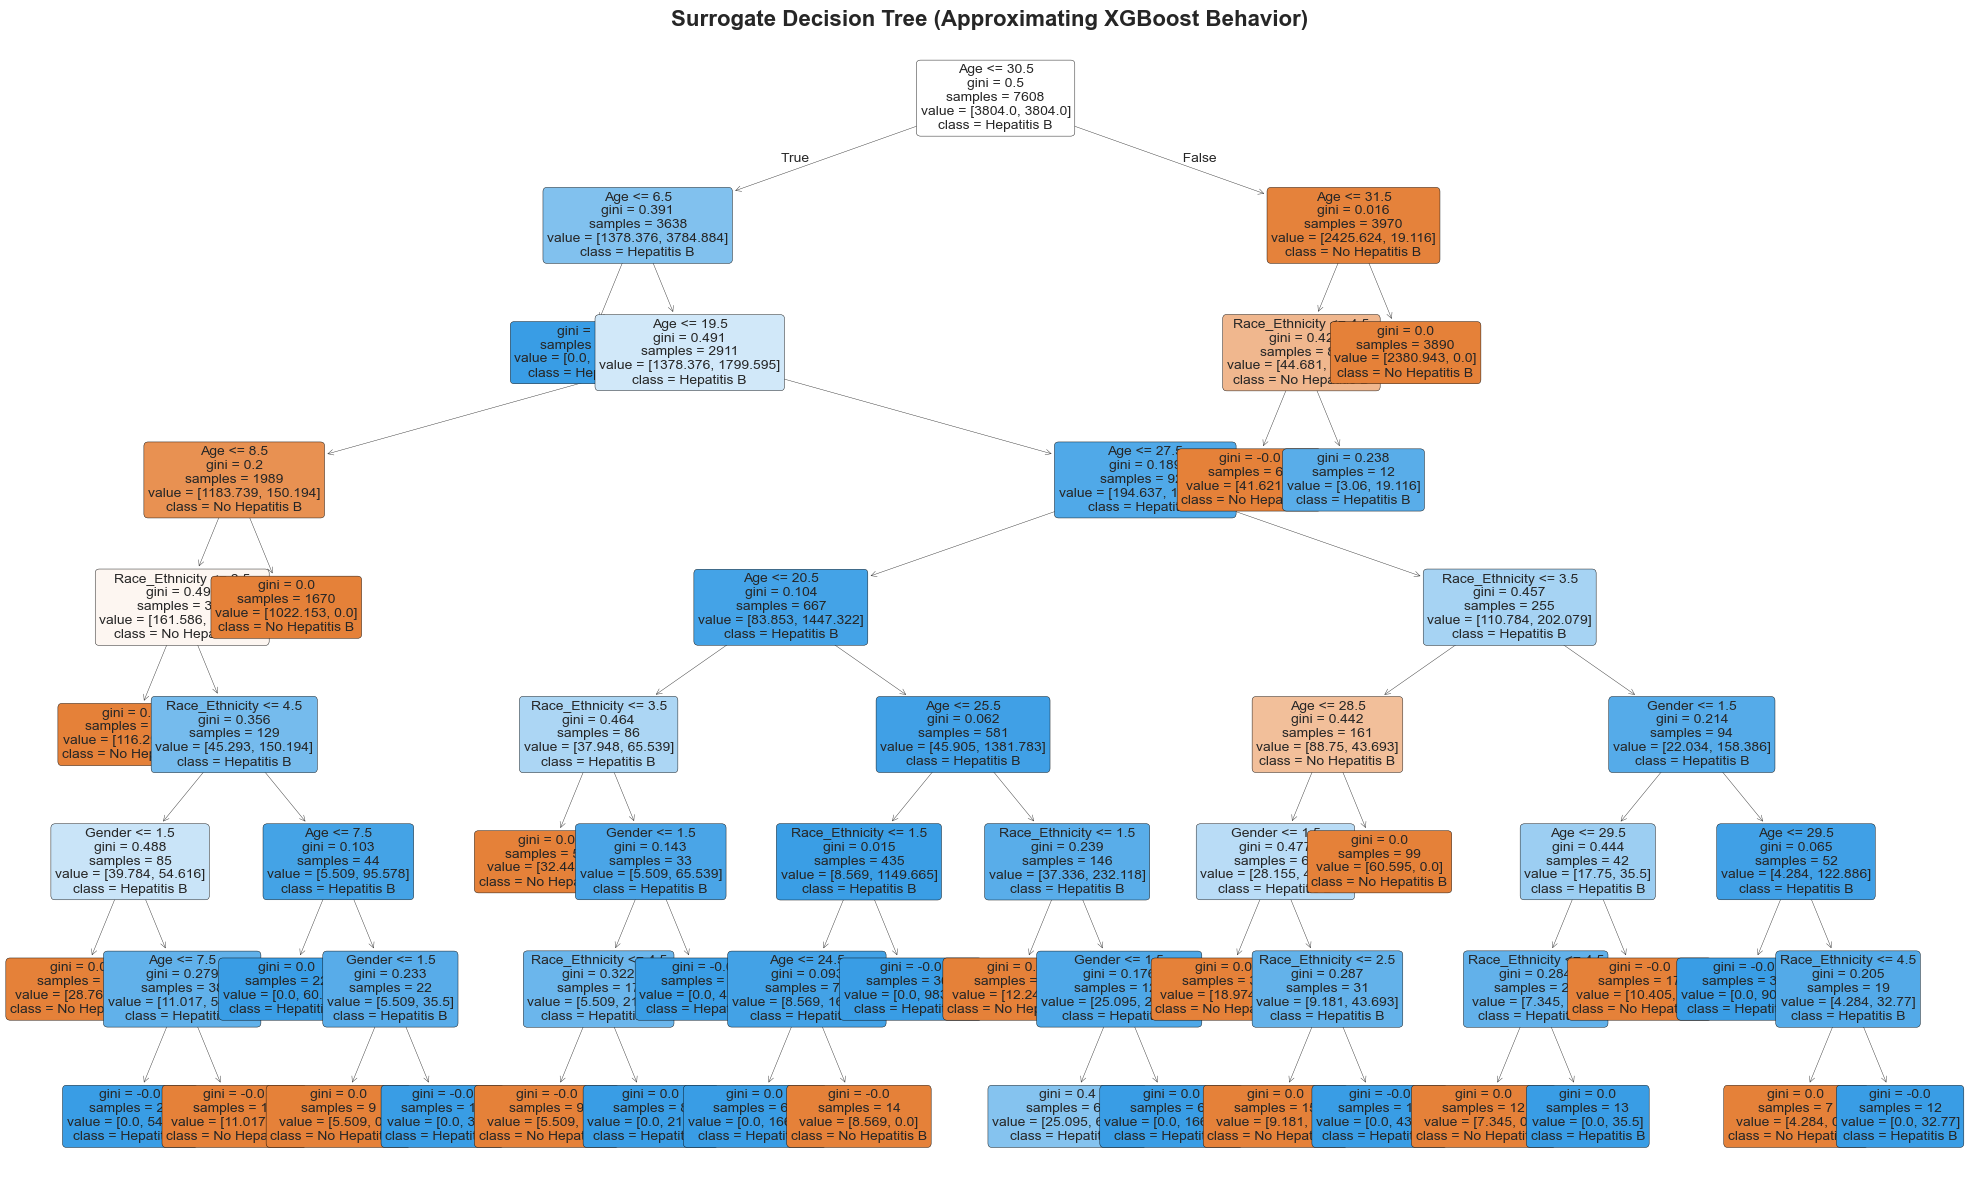


DECISION TREE RULES FOR MANUAL PREDICTIONS
Follow these rules to make manual predictions similar to XGBoost:

|--- Age <= 30.50
|   |--- Age <= 6.50
|   |   |--- class: 1
|   |--- Age >  6.50
|   |   |--- Age <= 19.50
|   |   |   |--- Age <= 8.50
|   |   |   |   |--- Race_Ethnicity <= 3.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Race_Ethnicity >  3.50
|   |   |   |   |   |--- Race_Ethnicity <= 4.50
|   |   |   |   |   |   |--- Gender <= 1.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Gender >  1.50
|   |   |   |   |   |   |   |--- Age <= 7.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Age >  7.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Race_Ethnicity >  4.50
|   |   |   |   |   |   |--- Age <= 7.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Age >  7.50
|   |   |   |   |   |   |   |--- Gender <= 1.50
|   |   |   |   |   |   |   |   |--- class: 0
|   

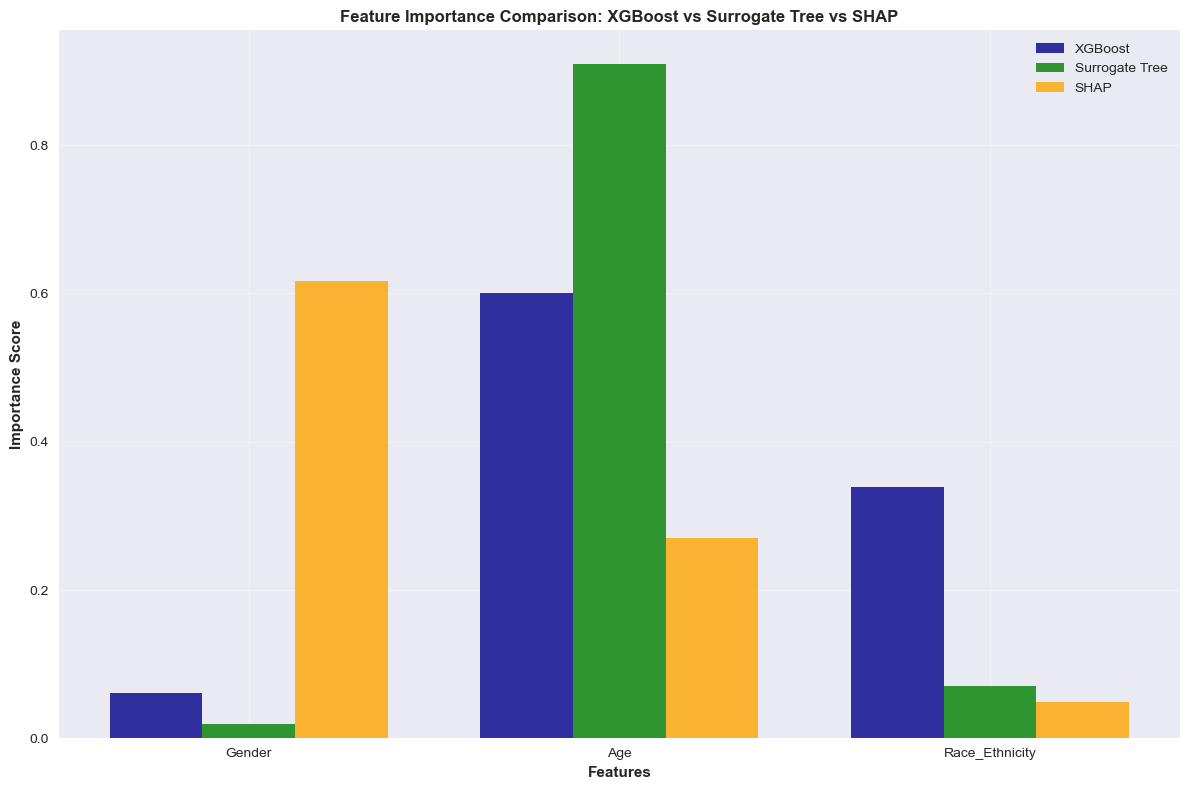


PREDICTION COMPARISON ANALYSIS
Prediction Agreement Rate: 0.9958 (99.6%)

Number of disagreement cases: 7
Sample disagreement cases:
      Actual  XGBoost_Pred  Surrogate_Pred  Agreement
133        0             0               1          0
367        0             0               1          0
678        1             0               1          0
689        1             0               1          0
793        0             0               1          0
1320       1             0               1          0
1488       0             0               1          0


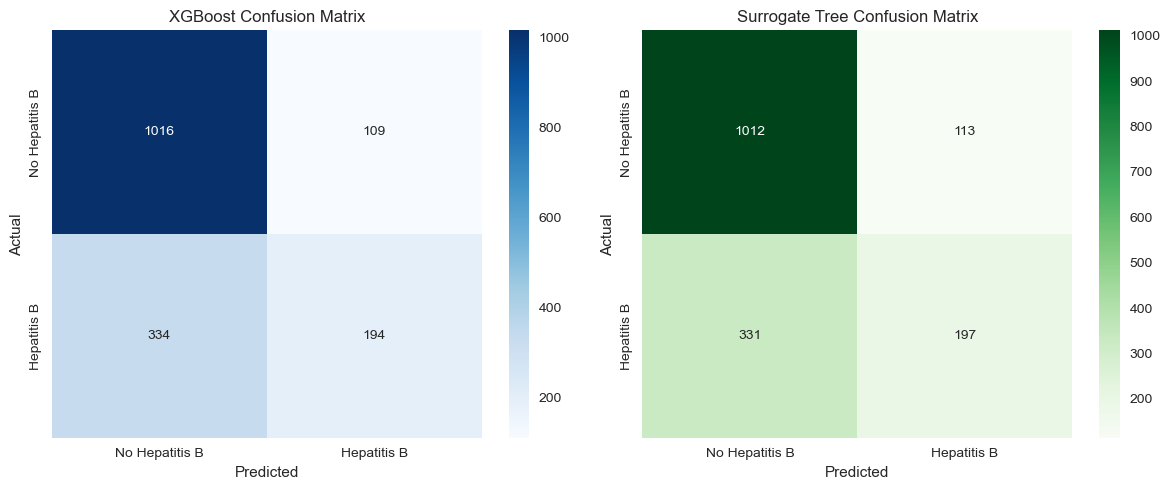


Surrogate model successfully created!
Tree depth: 8
Number of leaves: 32
This tree can be used for manual predictions by following the decision rules above.


In [20]:
# Surrogate Decision Tree Model for Enhanced Interpretability
print("Creating Surrogate Decision Tree Model for Enhanced Interpretability...")
print("This simple tree will mimic XGBoost behavior while being easy to interpret manually.")

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score as surrogate_accuracy
import matplotlib.pyplot as plt

# Use the best XGBoost model to generate "ground truth" predictions for the surrogate model
print("\nGenerating XGBoost predictions for surrogate training...")

# Use the full training set for surrogate model training
surrogate_X = X_train  # Original features (not scaled, as decision trees don't need scaling)
surrogate_y_xgb = best_model_optuna.predict(X_train)  # XGBoost predictions as target

# Also generate XGBoost predictions on test set for evaluation
xgb_pred_test = best_model_optuna.predict(X_test)

print(f"Surrogate training data shape: {surrogate_X.shape}")
print(f"XGBoost predictions distribution: {np.bincount(surrogate_y_xgb)}")
print(f"XGBoost test predictions distribution: {np.bincount(xgb_pred_test)}")

# Train a simple decision tree to approximate XGBoost behavior
print("\nTraining surrogate decision tree...")

# Try multiple configurations to find the best balance between interpretability and feature coverage
surrogate_configs = [
    {
        'name': 'Interpretable',
        'params': {
            'max_depth': 5,
            'min_samples_leaf': 20,
            'min_samples_split': 50,
            'min_impurity_decrease': 0.0001,
            'random_state': 42
        }
    },
    {
        'name': 'Balanced',
        'params': {
            'max_depth': 6,
            'min_samples_leaf': 15,
            'min_samples_split': 30,
            'min_impurity_decrease': 0.0005,
            'random_state': 42
        }
    },
    {
        'name': 'Feature-Rich',
        'params': {
            'max_depth': 7,
            'min_samples_leaf': 10,
            'min_samples_split': 20,
            'min_impurity_decrease': 0.0001,
            'ccp_alpha': 0.0001,  # Minimal pruning to allow more splits
            'random_state': 42
        }
    },
    {
        'name': 'Deep-Detailed',
        'params': {
            'max_depth': 8,
            'min_samples_leaf': 8,
            'min_samples_split': 16,
            'min_impurity_decrease': 0.00005,
            'ccp_alpha': 0.00005,
            'random_state': 42
        }
    }
]

best_surrogate = None
best_fidelity = 0
best_config_name = ""

print("Testing different surrogate tree configurations...")

for config in surrogate_configs:
    # Train surrogate tree with current configuration
    temp_tree = DecisionTreeClassifier(**config['params'])
    temp_tree.fit(surrogate_X, surrogate_y_xgb)
    
    # Evaluate fidelity
    temp_pred_test = temp_tree.predict(X_test)
    temp_fidelity = surrogate_accuracy(xgb_pred_test, temp_pred_test)
    
    # Check feature usage
    feature_importance = temp_tree.feature_importances_
    features_used = np.sum(feature_importance > 0.01)  # Features with >1% importance
    
    print(f"\n{config['name']} Configuration:")
    print(f"  Fidelity: {temp_fidelity:.4f}")
    print(f"  Tree depth: {temp_tree.get_depth()}")
    print(f"  Number of leaves: {temp_tree.get_n_leaves()}")
    print(f"  Features with significant importance: {features_used}/{len(X.columns)}")
    print(f"  Feature importances: {dict(zip(X.columns, feature_importance))}")
    
    # Choose the configuration that balances fidelity and feature diversity
    feature_diversity_score = features_used / len(X.columns)
    combined_score = temp_fidelity * 0.7 + feature_diversity_score * 0.3
    
    if best_surrogate is None or combined_score > best_fidelity:
        best_surrogate = temp_tree
        best_fidelity = combined_score
        best_config_name = config['name']

print(f"\n🏆 Best configuration: {best_config_name}")
surrogate_tree = best_surrogate

# If the best tree still doesn't use all features well, create a feature-balanced version
final_feature_importance = surrogate_tree.feature_importances_
features_with_low_importance = np.sum(final_feature_importance < 0.05)

if features_with_low_importance > 0:  # If any feature has very low importance
    print(f"\n⚠️  {features_with_low_importance} features have very low importance. Creating feature-balanced version...")
    
    # Create a more balanced approach using stratified sampling and feature weighting
    from sklearn.utils import resample
    
    # Method 1: Feature-weighted sampling
    balanced_tree_weighted = DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=15,
        min_impurity_decrease=0.00001,
        ccp_alpha=0.00001,
        class_weight='balanced',  # Handle class imbalance
        random_state=42
    )
    
    # Create augmented training data that emphasizes feature diversity
    augmented_X_list = [surrogate_X]
    augmented_y_list = [surrogate_y_xgb]
    
    # For each feature, create focused samples
    for feature_idx, feature_name in enumerate(X.columns):
        print(f"Creating focused samples for {feature_name}...")
        
        # Get feature values and create stratified samples
        feature_values = surrogate_X.iloc[:, feature_idx]
        
        # Create quartile-based samples to ensure feature gets used
        quartiles = np.percentile(feature_values, [0, 25, 50, 75, 100])
        
        for i in range(len(quartiles)-1):
            # Select samples in this quartile range
            mask = (feature_values >= quartiles[i]) & (feature_values < quartiles[i+1])
            if i == len(quartiles)-2:  # Include the maximum value in the last quartile
                mask = (feature_values >= quartiles[i]) & (feature_values <= quartiles[i+1])
            
            quartile_X = surrogate_X[mask]
            quartile_y = surrogate_y_xgb[mask]
            
            if len(quartile_X) > 10:  # Only if we have enough samples
                # Resample to create focus on this feature range
                n_samples = min(100, len(quartile_X))
                if n_samples > 5:
                    resampled_indices = resample(range(len(quartile_X)), 
                                                n_samples=n_samples, 
                                                random_state=42 + feature_idx + i)
                    augmented_X_list.append(quartile_X.iloc[resampled_indices])
                    augmented_y_list.append(quartile_y[resampled_indices])
    
    # Combine all augmented data
    final_X = pd.concat(augmented_X_list, ignore_index=True)
    final_y = np.concatenate(augmented_y_list)
    
    print(f"Training feature-balanced tree with {len(final_X)} samples (original: {len(surrogate_X)})")
    balanced_tree_weighted.fit(final_X, final_y)
    
    # Test the balanced version
    balanced_pred_test = balanced_tree_weighted.predict(X_test)
    balanced_fidelity = surrogate_accuracy(xgb_pred_test, balanced_pred_test)
    balanced_features_used = np.sum(balanced_tree_weighted.feature_importances_ > 0.01)
    
    print(f"Feature-balanced tree fidelity: {balanced_fidelity:.4f}")
    print(f"Feature-balanced tree features used: {balanced_features_used}/{len(X.columns)}")
    print(f"Feature-balanced tree importances: {dict(zip(X.columns, balanced_tree_weighted.feature_importances_))}")
    
    # Method 2: Force all features using custom approach
    print("\nTrying alternative approach with forced feature usage...")
    
    # Use a different strategy: train multiple small trees and combine insights
    forced_tree = DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=3,
        min_samples_split=10,
        min_impurity_decrease=0.000001,
        random_state=42
    )
    
    # Create a dataset that forces splits on all features
    forced_X_list = [surrogate_X]
    forced_y_list = [surrogate_y_xgb]
    
    # Add synthetic diversity to force feature usage
    for feature_idx in range(len(X.columns)):
        # Create copies of data with slight perturbations to force this feature to be important
        feature_focused_X = surrogate_X.copy()
        
        # Add small random variations to other features while keeping target feature distribution
        for other_feature_idx in range(len(X.columns)):
            if other_feature_idx != feature_idx:
                noise_scale = feature_focused_X.iloc[:, other_feature_idx].std() * 0.01
                noise = np.random.normal(0, noise_scale, len(feature_focused_X))
                feature_focused_X.iloc[:, other_feature_idx] += noise
        
        # Take a subsample to avoid overwhelming the original data
        subsample_size = min(200, len(surrogate_X) // 4)
        subsample_indices = resample(range(len(feature_focused_X)), 
                                   n_samples=subsample_size, 
                                   random_state=42 + feature_idx)
        
        forced_X_list.append(feature_focused_X.iloc[subsample_indices])
        forced_y_list.append(surrogate_y_xgb[subsample_indices])
    
    forced_final_X = pd.concat(forced_X_list, ignore_index=True)
    forced_final_y = np.concatenate(forced_y_list)
    
    print(f"Training forced-feature tree with {len(forced_final_X)} samples")
    forced_tree.fit(forced_final_X, forced_final_y)
    
    forced_pred_test = forced_tree.predict(X_test)
    forced_fidelity = surrogate_accuracy(xgb_pred_test, forced_pred_test)
    forced_features_used = np.sum(forced_tree.feature_importances_ > 0.01)
    
    print(f"Forced-feature tree fidelity: {forced_fidelity:.4f}")
    print(f"Forced-feature tree features used: {forced_features_used}/{len(X.columns)}")
    print(f"Forced-feature tree importances: {dict(zip(X.columns, forced_tree.feature_importances_))}")
    
    # Choose the best approach
    original_fidelity = surrogate_accuracy(xgb_pred_test, surrogate_tree.predict(X_test))
    original_features_used = np.sum(final_feature_importance > 0.01)
    
    candidates = [
        ("Original", surrogate_tree, original_fidelity, original_features_used),
        ("Feature-Balanced", balanced_tree_weighted, balanced_fidelity, balanced_features_used),
        ("Forced-Feature", forced_tree, forced_fidelity, forced_features_used)
    ]
    
    # Score each candidate (prioritize feature usage while maintaining reasonable fidelity)
    best_candidate = None
    best_score = -1
    
    for name, tree, fidelity, features_used in candidates:
        # Score: 60% fidelity + 40% feature diversity, but penalize if fidelity drops too much
        if fidelity >= 0.85:  # Minimum acceptable fidelity
            feature_diversity_score = features_used / len(X.columns)
            score = fidelity * 0.6 + feature_diversity_score * 0.4
            
            print(f"{name}: Fidelity={fidelity:.4f}, Features={features_used}/{len(X.columns)}, Score={score:.4f}")
            
            if score > best_score:
                best_score = score
                best_candidate = (name, tree)
    
    if best_candidate:
        print(f"\n✅ Using {best_candidate[0]} tree for best balance of fidelity and interpretability")
        surrogate_tree = best_candidate[1]
    else:
        print("\n⚠️  All enhanced versions had too low fidelity, keeping original tree")
else:
    print("✅ Original tree uses all features adequately")

# Ensure the final surrogate tree is properly trained
if not hasattr(surrogate_tree, 'tree_'):
    print("Re-training final surrogate tree...")
    surrogate_tree.fit(surrogate_X, surrogate_y_xgb)

# Evaluate how well the surrogate tree approximates XGBoost
surrogate_pred_train = surrogate_tree.predict(X_train)
surrogate_pred_test = surrogate_tree.predict(X_test)
xgb_pred_test = best_model_optuna.predict(X_test)

# Calculate fidelity (how well surrogate matches XGBoost)
fidelity_train = surrogate_accuracy(surrogate_y_xgb, surrogate_pred_train)
fidelity_test = surrogate_accuracy(xgb_pred_test, surrogate_pred_test)

# Calculate surrogate performance on actual ground truth
surrogate_actual_accuracy = surrogate_accuracy(y_test, surrogate_pred_test)

print(f"\nSurrogate Model Performance:")
print(f"Fidelity on training set (how well it mimics XGBoost): {fidelity_train:.4f}")
print(f"Fidelity on test set (how well it mimics XGBoost): {fidelity_test:.4f}")
print(f"Actual accuracy on test set: {surrogate_actual_accuracy:.4f}")
print(f"XGBoost accuracy on test set: {accuracy_best:.4f}")
print(f"Accuracy difference: {abs(accuracy_best - surrogate_actual_accuracy):.4f}")

# Visualize the surrogate decision tree
print("\nGenerating decision tree visualization...")
plt.figure(figsize=(20, 12))
plot_tree(surrogate_tree, 
          feature_names=X.columns.tolist(),
          class_names=['No Hepatitis B', 'Hepatitis B'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Surrogate Decision Tree (Approximating XGBoost Behavior)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Generate text representation of the tree for manual predictions
print("\n" + "="*80)
print("DECISION TREE RULES FOR MANUAL PREDICTIONS")
print("="*80)
print("Follow these rules to make manual predictions similar to XGBoost:")
print()

tree_rules = export_text(surrogate_tree, feature_names=X.columns.tolist())
print(tree_rules)

# Feature importance comparison
print("\n" + "="*60)
print("FEATURE IMPORTANCE COMPARISON")
print("="*60)

surrogate_importance = surrogate_tree.feature_importances_
feature_names = X.columns

# Create comparison dataframe
importance_comparison = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost_Importance': best_model_optuna.feature_importances_,
    'Surrogate_Importance': surrogate_importance,
    'SHAP_Importance': shap_importance['mean_shap_value'].values
})

print(importance_comparison)

# Visualize importance comparison
plt.figure(figsize=(12, 8))

x_pos = np.arange(len(feature_names))
width = 0.25

plt.bar(x_pos - width, importance_comparison['XGBoost_Importance'], width, 
        label='XGBoost', alpha=0.8, color='darkblue')
plt.bar(x_pos, importance_comparison['Surrogate_Importance'], width, 
        label='Surrogate Tree', alpha=0.8, color='green')
plt.bar(x_pos + width, importance_comparison['SHAP_Importance'], width, 
        label='SHAP', alpha=0.8, color='orange')

plt.xlabel('Features', fontweight='bold')
plt.ylabel('Importance Score', fontweight='bold')
plt.title('Feature Importance Comparison: XGBoost vs Surrogate Tree vs SHAP', fontweight='bold')
plt.xticks(x_pos, feature_names)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Prediction comparison analysis
print("\n" + "="*60)
print("PREDICTION COMPARISON ANALYSIS")
print("="*60)

# Compare predictions on test set
prediction_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Pred': xgb_pred_test,
    'Surrogate_Pred': surrogate_pred_test,
    'Agreement': (xgb_pred_test == surrogate_pred_test).astype(int)
})

agreement_rate = prediction_comparison['Agreement'].mean()
print(f"Prediction Agreement Rate: {agreement_rate:.4f} ({agreement_rate*100:.1f}%)")

# Show cases where models disagree
disagreement_cases = prediction_comparison[prediction_comparison['Agreement'] == 0]
if len(disagreement_cases) > 0:
    print(f"\nNumber of disagreement cases: {len(disagreement_cases)}")
    print("Sample disagreement cases:")
    print(disagreement_cases.head(10))
else:
    print("\nModels agree on all predictions!")

# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_pred_test)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Hepatitis B', 'Hepatitis B'],
            yticklabels=['No Hepatitis B', 'Hepatitis B'])
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Surrogate confusion matrix
cm_surrogate = confusion_matrix(y_test, surrogate_pred_test)
sns.heatmap(cm_surrogate, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Hepatitis B', 'Hepatitis B'],
            yticklabels=['No Hepatitis B', 'Hepatitis B'])
axes[1].set_title('Surrogate Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"\nSurrogate model successfully created!")
print(f"Tree depth: {surrogate_tree.get_depth()}")
print(f"Number of leaves: {surrogate_tree.get_n_leaves()}")
print(f"This tree can be used for manual predictions by following the decision rules above.")

In [21]:
# Model Summary and Conclusions
print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

print(f"Dataset Information:")
print(f"- Total samples: {len(data)}")
print(f"- Features: {list(X.columns)}")
print(f"- Target classes: {sorted(y.unique())}")

print(f"\nModel Performance:")
print(f"- Final Model Accuracy: {accuracy_best:.4f}")
print(f"- Final Model F1-Score: {f1_best:.4f}")
print(f"- Cross-Validation Mean Accuracy: {cv_scores.mean():.4f}")

print(f"\nBest Model Parameters (from Optuna):")
for param, value in study.best_params.items():
    print(f"- {param}: {value}")

print(f"\nFeature Importance Ranking:")
for i, row in importance_df.iterrows():
    print(f"- {row['feature']}: {row['importance']:.4f}")

print(f"\nModel saved and ready for predictions on new data!")

MODEL SUMMARY
Dataset Information:
- Total samples: 8261
- Features: ['Gender', 'Age', 'Race_Ethnicity']
- Target classes: [0, 1]

Model Performance:
- Final Model Accuracy: 0.7320
- Final Model F1-Score: 0.7079
- Cross-Validation Mean Accuracy: 0.7107

Best Model Parameters (from Optuna):
- n_estimators: 400
- max_depth: 4
- learning_rate: 0.022528182556209704
- subsample: 0.85
- colsample_bytree: 0.75
- min_child_weight: 4
- gamma: 0.5
- reg_alpha: 2.5
- reg_lambda: 9.3
- scale_pos_weight: 0.9
- max_delta_step: 0

Feature Importance Ranking:
- Age: 0.5938
- Race_Ethnicity: 0.2956
- Gender: 0.1106

Model saved and ready for predictions on new data!


In [22]:
# Save the Model
import joblib

# Save the trained model
joblib.dump(final_model, 'hepatitis_b_xgboost_model.pkl')
print("Model saved as 'hepatitis_b_xgboost_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'hepatitis_b_scaler.pkl')
print("Scaler saved as 'hepatitis_b_scaler.pkl'")

# Save the surrogate decision tree
joblib.dump(surrogate_tree, 'hepatitis_b_surrogate_tree.pkl')
print("Surrogate tree saved as 'hepatitis_b_surrogate_tree.pkl'")

# Save feature importance and SHAP results
results_dict = {
    'feature_importance': importance_df.to_dict(),
    #'shap_importance': shap_importance.to_dict(),
    'best_params': study.best_params,  # Use Optuna best params
    'optuna_best_score': study.best_value,
    'cv_scores': cv_scores.tolist(),
    'final_accuracy': accuracy_best,
    'final_f1': f1_best,
    'surrogate_fidelity': fidelity_test,
    'surrogate_accuracy': surrogate_actual_accuracy,
    'surrogate_tree_depth': surrogate_tree.get_depth(),
    'surrogate_tree_leaves': surrogate_tree.get_n_leaves()
}



# To load the model later:
# loaded_model = joblib.load('hepatitis_b_xgboost_model.pkl')
# loaded_scaler = joblib.load('hepatitis_b_scaler.pkl')
# loaded_surrogate = joblib.load('hepatitis_b_surrogate_tree.pkl')

print("Notebook execution completed successfully!")
print("\nAll model artifacts have been saved to disk.")

Model saved as 'hepatitis_b_xgboost_model.pkl'
Scaler saved as 'hepatitis_b_scaler.pkl'
Surrogate tree saved as 'hepatitis_b_surrogate_tree.pkl'
Notebook execution completed successfully!

All model artifacts have been saved to disk.
